In [1]:
import numpy as np
import pandas as pd
import json
import statsmodels.formula.api as smf
import statsmodels.api as sm

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Cargar dataset con índices (generado desde 02_indices + Paso 2.15)
RUTA_DATASET = "../../outputs/encuesta_percepcion_paso_2_15.csv"
df = pd.read_csv(RUTA_DATASET, encoding="utf-8-sig", low_memory=False)

print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
assert df.shape[0] == 13082, "Número de filas incorrecto"

# Cargar dim_localidad (opcional, para referencia)
dim_localidad = pd.read_csv("../dim_localidad.csv", encoding="utf-8-sig")
print(f"dim_localidad cargada: {dim_localidad.shape[0]} localidades")

# Cargar diseño muestral
with open("../diseno_muestral.json", "r", encoding="utf-8") as f:
    DISEÑO_MUESTRAL = json.load(f)
print("Diseño muestral cargado")

Dataset cargado: 13082 filas, 104 columnas
dim_localidad cargada: 20 localidades
Diseño muestral cargado


#Celda — Paso 3.1: Conteo de Jx402 y chequeo go/no-go

In [2]:
# --- Conteo de Jx402 (ya traducido a "Si"/"No" según diccionario cohesionado) ---
n_positivos = (df["Jx402"] == "Si").sum()
n_totales = len(df)
pct_positivos = n_positivos / n_totales * 100

print(f"Jx402 (violencia intrafamiliar — ¿fue víctima?):")
print(f"  Positivos (Sí): {n_positivos}")
print(f"  Total de encuestados: {n_totales}")
print(f"  Proporción: {pct_positivos:.2f}%")
print(f"  Umbral mínimo para modelación (150 casos): {'✅ ALCANZADO' if n_positivos >= 150 else 'NO ALCANZADO'}")

# --- Distribución de Jx403 (denuncia) — solo aplica a los 24 positivos ---
print("\nDistribución de Jx403 (¿denunció el delito?) — solo sobre los que respondieron Sí en Jx402:")
print(df.loc[df["Jx402"] == "Si", "Jx403"].value_counts(dropna=False))

Jx402 (violencia intrafamiliar — ¿fue víctima?):
  Positivos (Sí): 24
  Total de encuestados: 13082
  Proporción: 0.18%
  Umbral mínimo para modelación (150 casos): NO ALCANZADO

Distribución de Jx403 (¿denunció el delito?) — solo sobre los que respondieron Sí en Jx402:
Jx403
Si    17
No     7
Name: count, dtype: int64


In [3]:
texto_supuesto_3_1 = f"""
## Paso 3.1 — Chequeo go/no-go para modelación de victimización directa (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

`Jx402` (víctima de violencia intrafamiliar en el último año) tiene **24 casos positivos** de 13.082 encuestados (0,18%).

El umbral mínimo establecido en el diseño (150 casos) **no se alcanza**.

**Consecuencia:** los modelos de regresión logística con `Jx402` o `Jx403` como variable dependiente **quedan descartados**. El análisis de la Fase 3 procede exclusivamente por la **rama alternativa**:

- **Variable dependiente principal:** `IPSJ_C` (percepción de acceso a medios para denunciar) → usada en modelos de regresión lineal para H-A.
- **Variable dependiente alternativa:** `afronto_M` (TAC_M) → usada en modelos de regresión logística para H-A.

**Justificación:** esta decisión ya fue documentada en el Paso 1.3 del notebook `01_preparacion.ipynb` y se mantiene aquí para asegurar trazabilidad en la Fase 3.

**Distribución de `Jx403` (¿denunció el delito?):**
- Sí: 17
- No: 7
- Total: 24 (coincide con los positivos de `Jx402`)

**Nota cualitativa (no inferencial):** de los 24 casos positivos, 17 denunciaron y 7 no. Esta cifra **no se usa como estimación poblacional** debido al sesgo de selección: quien admite violencia intrafamiliar ante un encuestador en su hogar es desproporcionadamente quien ya denunció. El 71% de denuncia observado en este subconjunto no refuta el subregistro — lo confirma por otra vía.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_3_1)

print("Constancia del Paso 3.1 agregada a docs/supuestos.md")

Constancia del Paso 3.1 agregada a docs/supuestos.md


#Celda — Paso 3.2: Modelo M1 — barrera de acceso a la denuncia (IPSJ_C)

Celda — Preparación de datos para M1

In [4]:
cols_necesarias = [
    "IPSJ_C", "ICC_mujer", "HHI", "pobreza_subjetiva", "estrato_cat",
    "A6x3", "D1", "sexo_jefe", "GAD7_ordinal", "A4",
    "codigo_localidad", "codigo_UPL", "fexp_calp_anu",
]
faltantes = [c for c in cols_necesarias if c not in df.columns]
assert not faltantes, f"Faltan columnas en df: {faltantes}"

df_m1 = df[cols_necesarias].copy()

# Edad y edad^2 (no linealidad)
df_m1["edad"] = df_m1["A6x3"]
df_m1["edad_cuadrado"] = df_m1["edad"] ** 2

# Interacción obligatoria: ICC_mujer x D1 (específicamente mujeres, no hogares en general)
df_m1["es_mujer"] = (df_m1["D1"] == "Mujer").astype(int)
df_m1["ICC_mujer_x_mujer"] = df_m1["ICC_mujer"] * df_m1["es_mujer"]

n_antes = len(df_m1)
df_m1 = df_m1.dropna(subset=[
    "IPSJ_C", "ICC_mujer", "HHI", "pobreza_subjetiva", "estrato_cat",
    "edad", "D1", "sexo_jefe", "GAD7_ordinal", "A4",
    "codigo_localidad", "codigo_UPL", "fexp_calp_anu",
])
n_despues = len(df_m1)

print(f"n antes de dropna: {n_antes}")
print(f"n después de dropna (muestra M1): {n_despues}")
print(f"Filas excluidas: {n_antes - n_despues} ({(n_antes - n_despues) / n_antes * 100:.1f}%)")

assert 11000 <= n_despues <= 12500, (
    f"n={n_despues} fuera del rango esperado (~11.900, según n de IPSJ_C = 11.904 "
    f"menos las pérdidas de ICC_mujer/HHI en Fase 2). Revisar antes de continuar."
)

n antes de dropna: 13082
n después de dropna (muestra M1): 11850
Filas excluidas: 1232 (9.4%)


Celda — Ajuste del modelo M1

In [5]:
formula_m1 = (
    "IPSJ_C ~ ICC_mujer + ICC_mujer_x_mujer + HHI + pobreza_subjetiva "
    "+ C(estrato_cat) + edad + edad_cuadrado + C(D1) + C(sexo_jefe) "
    "+ C(GAD7_ordinal) + A4 + C(codigo_localidad)"
)

modelo_m1 = smf.wls(
    formula=formula_m1,
    data=df_m1,
    weights=df_m1["fexp_calp_anu"],
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m1["codigo_UPL"], "use_correction": True},
)

print(modelo_m1.summary())

                            WLS Regression Results                            
Dep. Variable:                 IPSJ_C   R-squared:                       0.036
Model:                            WLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                 5.844e+05
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           9.53e-77
Time:                        18:46:56   Log-Likelihood:                -19687.
No. Observations:               11850   AIC:                         3.945e+04
Df Residuals:                   11812   BIC:                         3.973e+04
Df Model:                          37                                         
Covariance Type:              cluster                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

c:\Users\tralf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 37, but rank is 29
  warnings.warn('covariance of constraints does not have full '


Celda — Extracción de coeficientes de interés y chequeo de signo esperado

In [6]:
predictores_interes = ["ICC_mujer", "ICC_mujer_x_mujer", "HHI"]

tabla_m1 = pd.DataFrame({
    "coef": modelo_m1.params[predictores_interes],
    "std_err": modelo_m1.bse[predictores_interes],
    "p_value": modelo_m1.pvalues[predictores_interes],
    "ci_low": modelo_m1.conf_int().loc[predictores_interes, 0],
    "ci_high": modelo_m1.conf_int().loc[predictores_interes, 1],
})
tabla_m1["signo_esperado"] = "Negativo"
tabla_m1["signo_observado"] = np.where(tabla_m1["coef"] < 0, "Negativo", "Positivo")
tabla_m1["coincide_signo_esperado"] = tabla_m1["signo_observado"] == tabla_m1["signo_esperado"]

print(tabla_m1.round(4))

n_modelo_m1 = int(modelo_m1.nobs)
r2_m1 = modelo_m1.rsquared

print(f"\nn del modelo: {n_modelo_m1}")
print(f"R²: {r2_m1:.4f}")
print(f"Número de conglomerados (codigo_UPL): {df_m1['codigo_UPL'].nunique()}")

                    coef  std_err  p_value  ci_low  ci_high signo_esperado  \
ICC_mujer         -0.264    0.075    0.000  -0.410   -0.118       Negativo   
ICC_mujer_x_mujer  0.178    0.075    0.017   0.032    0.324       Negativo   
HHI                0.266    0.065    0.000   0.139    0.393       Negativo   

                  signo_observado  coincide_signo_esperado  
ICC_mujer                Negativo                     True  
ICC_mujer_x_mujer        Positivo                    False  
HHI                      Positivo                    False  

n del modelo: 11850
R²: 0.0356
Número de conglomerados (codigo_UPL): 30


Celda — Robustez: repetir M1 con IBA como variable dependiente

In [7]:
cols_iba = ["IBA", "ICC_mujer", "HHI", "pobreza_subjetiva", "estrato_cat",
            "A6x3", "D1", "sexo_jefe", "GAD7_ordinal", "A4",
            "codigo_localidad", "codigo_UPL", "fexp_calp_anu"]
faltantes_iba = [c for c in cols_iba if c not in df.columns]
assert not faltantes_iba, f"Faltan columnas para el modelo IBA: {faltantes_iba}"

df_m1_iba = df[cols_iba].copy()
df_m1_iba["edad"] = df_m1_iba["A6x3"]
df_m1_iba["edad_cuadrado"] = df_m1_iba["edad"] ** 2
df_m1_iba["es_mujer"] = (df_m1_iba["D1"] == "Mujer").astype(int)
df_m1_iba["ICC_mujer_x_mujer"] = df_m1_iba["ICC_mujer"] * df_m1_iba["es_mujer"]

n_antes_iba = len(df_m1_iba)
df_m1_iba = df_m1_iba.dropna(subset=[
    "IBA", "ICC_mujer", "HHI", "pobreza_subjetiva", "estrato_cat",
    "edad", "D1", "sexo_jefe", "GAD7_ordinal", "A4",
    "codigo_localidad", "codigo_UPL", "fexp_calp_anu",
])
n_despues_iba = len(df_m1_iba)
print(f"n modelo IBA: {n_despues_iba} (esperado más bajo que M1, listwise sobre 3 ítems)")

formula_m1_iba = formula_m1.replace("IPSJ_C ~", "IBA ~")

modelo_m1_iba = smf.wls(
    formula=formula_m1_iba,
    data=df_m1_iba,
    weights=df_m1_iba["fexp_calp_anu"],
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m1_iba["codigo_UPL"], "use_correction": True},
)

tabla_m1_iba = pd.DataFrame({
    "coef": modelo_m1_iba.params[predictores_interes],
    "std_err": modelo_m1_iba.bse[predictores_interes],
    "p_value": modelo_m1_iba.pvalues[predictores_interes],
})
print("\nRobustez — mismo modelo con IBA como dependiente:")
print(tabla_m1_iba.round(4))

# Comparación de signos entre las dos especificaciones (IPSJ_C vs IBA)
comparacion_robustez = pd.DataFrame({
    "signo_IPSJ_C": np.where(tabla_m1["coef"] < 0, "Neg", "Pos"),
    "signo_IBA": np.where(tabla_m1_iba["coef"] < 0, "Neg", "Pos"),
})
comparacion_robustez["coinciden"] = comparacion_robustez["signo_IPSJ_C"] == comparacion_robustez["signo_IBA"]
print("\nConsistencia de signos entre especificaciones:")
print(comparacion_robustez)

n modelo IBA: 11307 (esperado más bajo que M1, listwise sobre 3 ítems)

Robustez — mismo modelo con IBA como dependiente:
                    coef  std_err  p_value
ICC_mujer          0.096    0.070    0.171
ICC_mujer_x_mujer -0.066    0.069    0.337
HHI               -0.229    0.048    0.000

Consistencia de signos entre especificaciones:
  signo_IPSJ_C signo_IBA  coinciden
0          Neg       Pos      False
1          Pos       Neg      False
2          Pos       Neg      False


In [8]:
from statsmodels.stats.multitest import multipletests

# Predictores de interés en el modelo M1 (IPSJ_C)
predictores_interes = ["ICC_mujer", "ICC_mujer_x_mujer", "HHI"]

# Extraer los p‑valores originales
pvals = tabla_m1.loc[predictores_interes, "p_value"].values

# Aplicar corrección de Benjamini-Hochberg (FDR) con α = 0.05
reject, pvals_corrected, _, _ = multipletests(
    pvals, alpha=0.05, method='fdr_bh'
)

# Mostrar resultados
print("Corrección de Benjamini-Hochberg para los 3 predictores de interés (M1):")
for pred, p_orig, p_corr, rej in zip(predictores_interes, pvals, pvals_corrected, reject):
    print(f"  {pred}:")
    print(f"    p original  = {p_orig:.6f}")
    print(f"    p ajustado  = {p_corr:.6f}")
    print(f"    rechaza H0? {rej}")

Corrección de Benjamini-Hochberg para los 3 predictores de interés (M1):
  ICC_mujer:
    p original  = 0.000406
    p ajustado  = 0.000608
    rechaza H0? True
  ICC_mujer_x_mujer:
    p original  = 0.017238
    p ajustado  = 0.017238
    rechaza H0? True
  HHI:
    p original  = 0.000043
    p ajustado  = 0.000128
    rechaza H0? True


In [9]:
# DOCUMENTACIÓN DEL PASO 3.2 — MODELO M1 (H-A)


# --- 1. Definir los resultados a documentar ---
# (Todos los valores se extraen de las salidas anteriores)

# 1a. Resultados del modelo principal (IPSJ_C)
n_m1 = 11850
r2_m1 = 0.0356  # se aproxima de 0.036 en el resumen
predictores = ["ICC_mujer", "ICC_mujer_x_mujer", "HHI"]
coefs_m1 = [-0.2637, 0.1777, 0.2658]
pvals_m1 = [0.000406, 0.017238, 0.000043]
ci_low_m1 = [-0.410, 0.032, 0.139]
ci_high_m1 = [-0.118, 0.324, 0.393]
signo_esperado = ["Negativo", "Negativo", "Negativo"]
signo_obs = ["Negativo", "Positivo", "Positivo"]

# 1b. p‑valores ajustados con BH (calculados manualmente para ser explícitos)
pvals_ajustados = [0.000608, 0.017238, 0.000128]
rechaza = [True, True, True]

# 1c. Resultados del modelo de robustez (IBA)
n_iba = 11307
coefs_iba = [0.0956, -0.0657, -0.2291]  # valores redondeados de la salida
pvals_iba = [0.171, 0.337, 0.000]
signo_iba = ["Positivo", "Negativo", "Negativo"]

# 2. Construir la tabla del modelo principal
tabla_m1_md = "| Predictor | Coef. | IC 95% | p‑valor | p‑valor ajustado (BH) | Signo esperado | Signo observado | ¿Coincide? |\n"
tabla_m1_md += "|-----------|-------|--------|---------|------------------------|----------------|-----------------|------------|\n"
for i, pred in enumerate(predictores):
    coincide = "Sí" if signo_esperado[i] == signo_obs[i] else "No"
    tabla_m1_md += f"| {pred} | {coefs_m1[i]:.3f} | [{ci_low_m1[i]:.3f}, {ci_high_m1[i]:.3f}] | {pvals_m1[i]:.6f} | {pvals_ajustados[i]:.6f} | {signo_esperado[i]} | {signo_obs[i]} | {coincide} |\n"

# 3. Construir la tabla de robustez (comparación de signos)
tabla_robustez_md = "| Predictor | Signo (IPSJ_C) | Signo (IBA) | ¿Coinciden? |\n"
tabla_robustez_md += "|-----------|----------------|-------------|-------------|\n"
for i, pred in enumerate(predictores):
    coincide = "Sí" if signo_obs[i] == signo_iba[i] else "No"
    tabla_robustez_md += f"| {pred} | {signo_obs[i]} | {signo_iba[i]} | {coincide} |\n"

# 4. Construir tabla de robustez con significancia
tabla_robustez_sig_md = "| Predictor | Coef. (IBA) | p‑valor (IBA) | Significativo (α=0.05) |\n"
tabla_robustez_sig_md += "|-----------|-------------|---------------|------------------------|\n"
for i, pred in enumerate(predictores):
    sig = "Sí" if pvals_iba[i] < 0.05 else "No"
    tabla_robustez_sig_md += f"| {pred} | {coefs_iba[i]:.3f} | {pvals_iba[i]:.3f} | {sig} |\n"

# 5. Escribir el texto completo en la bitácora
from datetime import datetime

texto = f"""
## Paso 3.2 — Modelo M1: barrera de acceso a la denuncia (IPSJ_C) y análisis de robustez (IBA)
**Fecha de ejecución:** {datetime.now().strftime('%Y-%m-%d')}

### 1. Especificación del modelo

- **Variable dependiente principal:** `IPSJ_C` (acceso percibido a la información y medios para denunciar delitos, escala 1–5).  
- **Variable dependiente alternativa (robustez):** `IBA` = −(z(IPSJ_A)+z(IPSJ_C)+z(IPSJ_E))/3, construido solo sobre los 11.361 casos con los tres ítems presentes.  
- **Predictores de interés:**  
  - `ICC_mujer` (Índice de Concentración del Cuidado Femenino, continuo 0–1)  
  - `ICC_mujer_x_mujer` (interacción entre `ICC_mujer` y la variable binaria `es_mujer` = 1 si D1 == "Mujer")  
  - `HHI` (Índice de Herfindahl de concentración del cuidado general, continuo 0–1)  

- **Controles:** pobreza subjetiva (`pobreza_bin`), estrato (`estrato_modelo`), edad (`A6x3`) y su cuadrado, sexo (`D1`), sexo del jefe de hogar (`sexo_jefe`), GAD‑7 (`gad7_ord`), presencia de menores en el hogar (`A4`), y efectos fijos de `codigo_localidad`.

- **Diseño muestral:**  
  - Estimación ponderada con `fexp_calp_anu`.  
  - Errores estándar clusterizados por `codigo_UPL` (30 conglomerados) con corrección de muestras pequeñas (`use_correction=True`).  
  - Eliminación por listwise de cualquier fila con valores faltantes en las variables del modelo.

---

### 2. Resultados del modelo principal (dependiente = IPSJ_C)

- **Muestra analítica:** {n_m1} de 13.082 encuestados (pérdida del 9,4%).  
- **R²:** {r2_m1:.4f} (el modelo explica una fracción muy pequeña de la varianza).

{tabla_m1_md}

- **Corrección de Benjamini‑Hochberg:** aplicada a los tres p‑valores con α = 0.05. Todos son significativos tras la corrección.

**Interpretación de los predictores de interés:**

1. **`ICC_mujer`** (β = {coefs_m1[0]:.3f}, p‑ajustado = {pvals_ajustados[0]:.6f}):  
   Por cada aumento unitario en la concentración femenina del cuidado, el acceso percibido a la denuncia **disminuye** en 0.26 puntos en la escala 1–5. **El signo es el esperado** y es estadísticamente significativo.

2. **`ICC_mujer_x_mujer`** (β = {coefs_m1[1]:.3f}, p‑ajustado = {pvals_ajustados[1]:.6f}):  
   La interacción es **positiva**. Esto implica que el efecto negativo de `ICC_mujer` se **atenúa** cuando la persona encuestada es mujer, en lugar de intensificarse como predecía la hipótesis. **El signo es contrario al esperado**.

3. **`HHI`** (β = {coefs_m1[2]:.3f}, p‑ajustado = {pvals_ajustados[2]:.6f}):  
   La concentración general del cuidado (independientemente del sexo de quien lo realiza) se asocia con **mayor** acceso a la denuncia. **El signo es contrario al esperado** (la hipótesis anticipaba que una mayor concentración → mayor barrera).

---

### 3. Análisis de robustez con IBA

Para verificar si el resultado depende de la definición de "barrera de acceso", se reestimó el mismo modelo usando `IBA` como variable dependiente.

- **Muestra analítica:** {n_iba} (pérdida adicional por listwise sobre ítems `IPSJ_A`, `IPSJ_C`, `IPSJ_E`).  

{tabla_robustez_sig_md}

**Comparación de signos entre especificaciones:**

{tabla_robustez_md}

---

### 4. Conclusión sobre H‑A

La hipótesis H‑A establecía que:

> *"La concentración femenina del cuidado se asocia con menor acceso percibido a la denuncia, y este efecto es más fuerte entre las mujeres."*

**Evaluación según criterios preregistrados (Sección 1.3 y 1.4):**

- **Criterio de significancia:** `ICC_mujer` es significativa en el modelo principal (p‑ajustado < 0.05). Por lo tanto, **no se refuta formalmente** la hipótesis.
- **Criterio de coherencia teórica:** la interacción `ICC_mujer_x_mujer` tiene signo **positivo** (opuesto al esperado), y `HHI` también. Esto indica que el mecanismo propuesto (un efecto específico y agravado para las mujeres) **no se sostiene**.
- **Criterio de robustez:** al cambiar la variable dependiente a `IBA`, los signos de los tres predictores de interés **se invierten** y los dos primeros pierden significancia. El resultado es **frágil**.

**Declaración final:**  
El modelo M1 proporciona evidencia **débil y parcial** para H‑A. La asociación negativa entre `ICC_mujer` e `IPSJ_C` es estadísticamente significativa y con el signo esperado, pero la interacción con el sexo no respalda el mecanismo hipotetizado, y el hallazgo no es robusto al usar una definición alternativa de la variable dependiente.  
En la sustentación se presentará como un **resultado mixto** que no permite confirmar la hipótesis de forma concluyente, y se señalarán las limitaciones (bajo R², sesgo de selección por la construcción de `ICC_mujer`, y baja consistencia interna de `IBA`).

"""

# Escribir en la bitácora
with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto)

print("Documentación del Paso 3.2 agregada a docs/supuestos.md")
print(f"   - Modelo principal (IPSJ_C): n = {n_m1}, R² = {r2_m1:.4f}")
print(f"   - Modelo robustez (IBA): n = {n_iba}")
print("   - Se registran signos, p‑valores ajustados y conclusión metodológica.")

Documentación del Paso 3.2 agregada a docs/supuestos.md
   - Modelo principal (IPSJ_C): n = 11850, R² = 0.0356
   - Modelo robustez (IBA): n = 11307
   - Se registran signos, p‑valores ajustados y conclusión metodológica.


#Celda — Paso 3.3: Modelo M2 (regresión logística, afrontamiento)

In [10]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# --- Variables del modelo (mismas que M1, cambiando la dependiente a binaria) ---
df["es_mujer"] = (df["D1"] == "Mujer").astype(int)
df["ICC_mujer_x_mujer"] = df["ICC_mujer"] * df["es_mujer"]

vars_modelo_m2 = [
    "afronto_M", "ICC_mujer", "ICC_mujer_x_mujer", "HHI",
    "pobreza_bin", "estrato_modelo", "edad", "edad2",
    "D1", "sexo_jefe", "gad7_ord", "A4",
    "codigo_localidad", "codigo_UPL", "fexp_calp_anu",
]

df_m2 = df[vars_modelo_m2].dropna().copy()
df_m2["codigo_localidad"] = df_m2["codigo_localidad"].astype(str)
df_m2["codigo_UPL"] = df_m2["codigo_UPL"].astype(str)

n_total = len(df)
n_modelo = len(df_m2)
n_positivos_modelo = int(df_m2["afronto_M"].sum())

print(f"Muestra analítica: {n_modelo} de {n_total} (pérdida del {(1 - n_modelo/n_total)*100:.1f}%)")
print(f"Positivos en la muestra analítica: {n_positivos_modelo} "
      f"({n_positivos_modelo/n_modelo*100:.2f}%)")

# --- Especificación del modelo (logística ponderada, EE clusterizados por codigo_UPL) ---
formula_m2 = (
    "afronto_M ~ ICC_mujer + ICC_mujer_x_mujer + HHI "
    "+ pobreza_bin + C(estrato_modelo) + edad + edad2 "
    "+ C(D1) + C(sexo_jefe) + gad7_ord + A4 "
    "+ C(codigo_localidad)"
)

modelo_m2 = smf.glm(
    formula=formula_m2,
    data=df_m2,
    family=sm.families.Binomial(),
    var_weights=df_m2["fexp_calp_anu"],
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m2["codigo_UPL"], "use_correction": True},
)

print(f"\nPseudo-R² (McFadden): {1 - modelo_m2.llf / modelo_m2.llnull:.4f}")

# --- Extraer solo los predictores de interés (no los efectos fijos de localidad) ---
predictores_interes = ["ICC_mujer", "ICC_mujer_x_mujer", "HHI"]

resumen_m2 = pd.DataFrame({
    "coef": modelo_m2.params[predictores_interes],
    "or": np.exp(modelo_m2.params[predictores_interes]),  # odds ratio
    "ic_inf": modelo_m2.conf_int().loc[predictores_interes, 0],
    "ic_sup": modelo_m2.conf_int().loc[predictores_interes, 1],
    "p_valor": modelo_m2.pvalues[predictores_interes],
})

# Corrección de Benjamini-Hochberg
from statsmodels.stats.multitest import multipletests
_, p_ajustados, _, _ = multipletests(resumen_m2["p_valor"], alpha=0.05, method="fdr_bh")
resumen_m2["p_ajustado_bh"] = p_ajustados

print("\nResultados del Modelo M2 (dependiente = afronto_M, logística):")
print(resumen_m2.round(4).to_string())

signos_esperados_m2 = {
    "ICC_mujer": "?",  # H-A(M2) no fija signo para ICC_mujer sola, solo para la interacción
    "ICC_mujer_x_mujer": "Negativo",  # OR < 1 esperado
    "HHI": "?",
}
resumen_m2["signo_observado"] = np.where(resumen_m2["coef"] > 0, "Positivo", "Negativo")
print("\nSigno esperado vs observado (según H-A M2, Sección 1.1):")
for pred in predictores_interes:
    print(f"  {pred}: esperado={signos_esperados_m2[pred]}, "
          f"observado={resumen_m2.loc[pred, 'signo_observado']}, "
          f"OR={resumen_m2.loc[pred, 'or']:.3f}")

Muestra analítica: 13022 de 13082 (pérdida del 0.5%)
Positivos en la muestra analítica: 2460 (18.89%)

Pseudo-R² (McFadden): 0.0750

Resultados del Modelo M2 (dependiente = afronto_M, logística):
                    coef    or  ic_inf  ic_sup  p_valor  p_ajustado_bh
ICC_mujer          0.017 1.017  -0.430   0.464    0.940          0.940
ICC_mujer_x_mujer  0.183 1.201  -0.363   0.729    0.511          0.767
HHI               -0.284 0.752  -0.593   0.024    0.071          0.213

Signo esperado vs observado (según H-A M2, Sección 1.1):
  ICC_mujer: esperado=?, observado=Positivo, OR=1.017
  ICC_mujer_x_mujer: esperado=Negativo, observado=Positivo, OR=1.201
  HHI: esperado=?, observado=Negativo, OR=0.753


c:\Users\tralf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1655: SpecificationWarning: cov_type not fully supported with var_weights
  warnings.warn('cov_type not fully supported with var_weights',


In [11]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np
from statsmodels.stats.multitest import multipletests

# --- Normalizar pesos: de var_weights (escala poblacional) a freq_weights (suman n) ---
# Preserva el peso RELATIVO de cada fila (mismo perfil de ponderación que var_weights),
# pero ya no se interpreta como "millones de personas" sino como "conteo de repetición"
# aproximado -- lo que sí soporta correctamente cov_type='cluster' en GLM.
df_m2["freq_w"] = df_m2["fexp_calp_anu"] / df_m2["fexp_calp_anu"].sum() * len(df_m2)

print(f"Suma de freq_w: {df_m2['freq_w'].sum():.1f} (debe ≈ n = {len(df_m2)})")
print(f"Rango de freq_w: [{df_m2['freq_w'].min():.4f}, {df_m2['freq_w'].max():.4f}]")

# --- Reajustar el modelo con freq_weights en vez de var_weights ---
formula_m2 = (
    "afronto_M ~ ICC_mujer + ICC_mujer_x_mujer + HHI "
    "+ pobreza_bin + C(estrato_modelo) + edad + edad2 "
    "+ C(D1) + C(sexo_jefe) + gad7_ord + A4 "
    "+ C(codigo_localidad)"
)

modelo_m2_corregido = smf.glm(
    formula=formula_m2,
    data=df_m2,
    family=sm.families.Binomial(),
    freq_weights=df_m2["freq_w"],
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m2["codigo_UPL"], "use_correction": True},
)

print(f"\nPseudo-R² (McFadden): {1 - modelo_m2_corregido.llf / modelo_m2_corregido.llnull:.4f}")

# --- Resultados de los predictores de interés ---
predictores_interes = ["ICC_mujer", "ICC_mujer_x_mujer", "HHI"]

resumen_m2_corregido = pd.DataFrame({
    "coef": modelo_m2_corregido.params[predictores_interes],
    "or": np.exp(modelo_m2_corregido.params[predictores_interes]),
    "ic_inf": modelo_m2_corregido.conf_int().loc[predictores_interes, 0],
    "ic_sup": modelo_m2_corregido.conf_int().loc[predictores_interes, 1],
    "p_valor": modelo_m2_corregido.pvalues[predictores_interes],
})

_, p_ajustados, _, _ = multipletests(resumen_m2_corregido["p_valor"], alpha=0.05, method="fdr_bh")
resumen_m2_corregido["p_ajustado_bh"] = p_ajustados

print("\nResultados del Modelo M2 corregido (freq_weights, cov_type='cluster' totalmente soportado):")
print(resumen_m2_corregido.round(4).to_string())

# --- Comparación directa: coeficientes deben ser casi idénticos; EE pueden diferir ---
comparacion = pd.DataFrame({
    "coef_var_weights": modelo_m2.params[predictores_interes],
    "coef_freq_weights": modelo_m2_corregido.params[predictores_interes],
    "se_var_weights": modelo_m2.bse[predictores_interes],
    "se_freq_weights": modelo_m2_corregido.bse[predictores_interes],
    "p_var_weights": modelo_m2.pvalues[predictores_interes],
    "p_freq_weights": modelo_m2_corregido.pvalues[predictores_interes],
})
print("\nComparación var_weights (con warning) vs freq_weights (corregido):")
print(comparacion.round(4).to_string())

Suma de freq_w: 13022.0 (debe ≈ n = 13022)
Rango de freq_w: [0.0056, 16.0139]

Pseudo-R² (McFadden): 0.0750

Resultados del Modelo M2 corregido (freq_weights, cov_type='cluster' totalmente soportado):
                    coef    or  ic_inf  ic_sup  p_valor  p_ajustado_bh
ICC_mujer          0.017 1.017  -0.430   0.464    0.940          0.940
ICC_mujer_x_mujer  0.183 1.201  -0.363   0.729    0.511          0.767
HHI               -0.284 0.752  -0.593   0.024    0.071          0.213

Comparación var_weights (con warning) vs freq_weights (corregido):
                   coef_var_weights  coef_freq_weights  se_var_weights  se_freq_weights  p_var_weights  p_freq_weights
ICC_mujer                     0.017              0.017           0.228            0.228          0.940           0.940
ICC_mujer_x_mujer             0.183              0.183           0.278            0.278          0.511           0.511
HHI                          -0.284             -0.284           0.158            0.158   

c:\Users\tralf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


In [12]:
from tqdm import tqdm
from scipy import stats as sp_stats

np.random.seed(2026)  # misma semilla que el resto del proyecto (Paso 0.3)

N_BOOTSTRAP = 500

# ============================================================
# Bootstrap por conglomerado (UPL)
# ============================================================

conglomerados = df_m2["codigo_UPL"].unique()
n_conglomerados = len(conglomerados)

coefs_bootstrap = {pred: [] for pred in predictores_interes}
n_fallidas = 0

for b in tqdm(
    range(N_BOOTSTRAP),
    desc="Bootstrap por conglomerado (UPL)"
):
    
    # Remuestrear conglomerados CON reemplazo
    # (no filas individuales)
    conglomerados_muestra = np.random.choice(
        conglomerados,
        size=n_conglomerados,
        replace=True
    )

    # Reconstruir el dataframe de la réplica
    # Si un conglomerado aparece varias veces,
    # sus filas aparecen varias veces con índices distintos
    partes = [
        df_m2[df_m2["codigo_UPL"] == c]
        for c in conglomerados_muestra
    ]

    df_boot = pd.concat(partes, ignore_index=True)

    try:
        modelo_boot = smf.glm(
            formula=formula_m2,
            data=df_boot,
            family=sm.families.Binomial(),
            var_weights=df_boot["fexp_calp_anu"],
        ).fit()

        for pred in predictores_interes:
            coefs_bootstrap[pred].append(
                modelo_boot.params[pred]
            )

    except Exception:
        n_fallidas += 1
        continue


# ============================================================
# Resumen del bootstrap
# ============================================================

print(
    f"\nRéplicas fallidas (no convergencia): "
    f"{n_fallidas} de {N_BOOTSTRAP}"
)

print(
    f"Réplicas completadas: "
    f"{N_BOOTSTRAP - n_fallidas} de {N_BOOTSTRAP}"
)


# ============================================================
# Construir tabla final con EE bootstrap
# ============================================================

resumen_m2_bootstrap = pd.DataFrame({
    "coef": modelo_m2.params[predictores_interes],
    "or": np.exp(modelo_m2.params[predictores_interes]),
    "se_bootstrap": [
        np.std(coefs_bootstrap[p], ddof=1)
        for p in predictores_interes
    ],
})

# Intervalos de confianza del 95 %
resumen_m2_bootstrap["ic_inf"] = (
    resumen_m2_bootstrap["coef"]
    - 1.96 * resumen_m2_bootstrap["se_bootstrap"]
)

resumen_m2_bootstrap["ic_sup"] = (
    resumen_m2_bootstrap["coef"]
    + 1.96 * resumen_m2_bootstrap["se_bootstrap"]
)

# Estadístico Z
resumen_m2_bootstrap["z"] = (
    resumen_m2_bootstrap["coef"]
    / resumen_m2_bootstrap["se_bootstrap"]
)

# P-valor bilateral
resumen_m2_bootstrap["p_valor"] = (
    2
    * (
        1
        - sp_stats.norm.cdf(
            np.abs(resumen_m2_bootstrap["z"])
        )
    )
)


# ============================================================
# Corrección por comparaciones múltiples: Benjamini-Hochberg
# ============================================================

_, p_ajustados_boot, _, _ = multipletests(
    resumen_m2_bootstrap["p_valor"],
    alpha=0.05,
    method="fdr_bh"
)

resumen_m2_bootstrap["p_ajustado_bh"] = p_ajustados_boot


# ============================================================
# Resultados finales
# ============================================================

print(
    "\nResultados del Modelo M2 con EE por "
    "bootstrap de conglomerados (definitivo):"
)

print(
    resumen_m2_bootstrap.round(4).to_string()
)


# ============================================================
# Comparación de errores estándar
# ============================================================

print(
    "\nComparación EE analítico (statsmodels, no soportado) "
    "vs EE bootstrap (confiable):"
)

comparacion_final = pd.DataFrame({
    "se_analitico_statsmodels": modelo_m2.bse[predictores_interes],
    "se_bootstrap": resumen_m2_bootstrap["se_bootstrap"],
})

print(
    comparacion_final.round(4).to_string()
)

Bootstrap por conglomerado (UPL): 100%|██████████| 500/500 [02:12<00:00,  3.78it/s]


Réplicas fallidas (no convergencia): 0 de 500
Réplicas completadas: 500 de 500

Resultados del Modelo M2 con EE por bootstrap de conglomerados (definitivo):
                    coef    or  se_bootstrap  ic_inf  ic_sup      z  p_valor  p_ajustado_bh
ICC_mujer          0.017 1.017         0.242  -0.456   0.491  0.071    0.943          0.943
ICC_mujer_x_mujer  0.183 1.201         0.283  -0.371   0.737  0.647    0.518          0.777
HHI               -0.284 0.752         0.147  -0.573   0.004 -1.930    0.054          0.161

Comparación EE analítico (statsmodels, no soportado) vs EE bootstrap (confiable):
                   se_analitico_statsmodels  se_bootstrap
ICC_mujer                             0.228         0.242
ICC_mujer_x_mujer                     0.278         0.283
HHI                                   0.158         0.147


In [13]:
texto_supuesto_3_3 = f"""
## Paso 3.3 — Modelo M2: afrontamiento de violencia presenciada (afronto_M, logístico) (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

### Especificación

Misma estructura de controles y diseño muestral que M1 (Paso 3.2): ponderación
`fexp_calp_anu`, efectos fijos de `codigo_localidad`, listwise deletion.

- **Muestra analítica:** 13.022 de 13.082 (pérdida 0,5% — mínima, porque `afronto_M` no
  tiene la pérdida de nulos que sí tienen `IPSJ_C`/`IBA`).
- **Positivos:** 2.460 (18,89%) — consistente con la TAC_M reportada en el Paso 2.8.
- **Pseudo-R² (McFadden):** 0,0750.

### Validación de robustez del error estándar (tres métodos)

Se corrió el modelo con tres estrategias de ponderación/inferencia, dado que
`statsmodels` advirtió que `cov_type='cluster'` no está totalmente soportado con
`var_weights`:

| Método | Coef. idénticos a los otros | SE | Estado |
|---|---|---|---|
| `var_weights` (original) | — | 0,228 / 0,278 / 0,158 | Warning de statsmodels |
| `freq_weights` (corregido) | Sí, exactos | 0,228 / 0,278 / 0,158 | cov_type totalmente soportado |
| Bootstrap por conglomerado UPL (500 réplicas, 0 fallidas) | Sí, exactos | 0,242 / 0,283 / 0,147 | **Método definitivo** |

**Los tres métodos convergen en los mismos coeficientes puntuales**, y los errores
estándar por bootstrap (el método sin supuestos asintóticos sobre el manejo de pesos)
son muy cercanos a los analíticos — confirma que el warning de statsmodels no ocultaba
un problema sustantivo. Se reportan los resultados del bootstrap como definitivos.

### Resultados (bootstrap, definitivos)

| Predictor | Coef. | OR | IC 95% | p (BH) | Signo esperado (Sección 1.1) | Signo observado | ¿Coincide? |
|---|---|---|---|---|---|---|---|
| `ICC_mujer` | 0,017 | 1,017 | [-0,456, 0,491] | 0,943 | No declarado explícitamente para el efecto principal | Positivo, nulo | N/A |
| `ICC_mujer_x_mujer` | 0,183 | 1,201 | [-0,371, 0,737] | 0,777 | **Negativo (OR<1)** | Positivo (OR>1) | **No** |
| `HHI` | -0,284 | 0,752 | [-0,573, 0,004] | 0,161 | No declarado explícitamente | Negativo | N/A |

**Ninguno de los tres predictores es significativo tras corrección Benjamini-Hochberg**
(α=0,05). `HHI` es el más cercano (p_ajustado=0,161), con un IC 95% que casi excluye el
0 pero no lo logra (límite superior 0,004).

### Evaluación de H-A (M2) según criterios preregistrados

> H-A (M2): *"...y con menor probabilidad de afrontar violencia presenciada"*, predictor
> de interés `ICC_mujer × D1`, signo esperado **OR < 1**.

- **Criterio de significancia:** la interacción `ICC_mujer_x_mujer` **no es significativa**
  tras BH (p_ajustado=0,777). Bajo el criterio preregistrado (Sección 1.4, escenario 2),
  esto es evidencia que **no soporta** H-A (M2).
- **Criterio de coherencia teórica:** aun ignorando la significancia, el signo observado
  de la interacción es **positivo** (OR=1,201) — opuesto al esperado (OR<1). No hay
  ninguna lectura del coeficiente puntual que respalde el mecanismo hipotetizado.
- **Consistencia con M1:** en el Paso 3.2, la misma interacción (`ICC_mujer_x_mujer`)
  sobre `IPSJ_C` también arrojó signo positivo (contrario a lo esperado), aunque en ese
  caso sí alcanzaba significancia. Aquí, ni siquiera hay significancia. **Los dos modelos
  de H-A (M1 y M2) coinciden en el mismo signo contrario a la hipótesis para la
  interacción con sexo** — no es un resultado aislado de una sola especificación.

### Declaración final — H-A (M2)

**No se encuentra evidencia que soporte H-A (M2).** La interacción `ICC_mujer × D1` no
es estadísticamente significativa sobre la probabilidad de afrontamiento de violencia
presenciada, y el signo puntual observado es opuesto al hipotetizado. Combinado con el
resultado de M1 (mixto, con la misma interacción de signo contrario), el patrón
consistente entre ambos modelos sugiere que **el mecanismo específico de "mujeres
sobrecargadas de cuidado tienen particularmente menor acceso/afrontamiento" no encuentra
sustento empírico en esta base**, más allá del efecto principal débil y no consistentemente
robusto de `ICC_mujer` documentado en M1.

Este resultado se reportará en la sustentación como parte de la evaluación conjunta de
H-A (M1+M2): evidencia débil, parcial y no robusta para el efecto principal, y ausencia
de evidencia — con signo contrario — para el mecanismo de interacción con sexo que era
el componente central de la hipótesis.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_3_3)

print("Constancia del Paso 3.3 (Modelo M2) agregada a docs/supuestos.md")

Constancia del Paso 3.3 (Modelo M2) agregada a docs/supuestos.md


#Celda — Paso 3.4: Modelo M3 — ICG_B como variable dependiente (no-injerencia / confianza vecinal)

In [14]:
# --- Insumo adicional respecto a M1/M2: TAC de la localidad como regresor ---
# TAC_M por codigo_localidad, ponderada (ya calculada en Fase 2 — Paso 2.8)
tac_localidad = (
    df.groupby("codigo_localidad")
    .apply(lambda g: np.average(g["afronto_M"], weights=g["fexp_calp_anu"]), include_groups=False)
    .rename("TAC_M_localidad")
)

df_m3 = df.merge(tac_localidad, on="codigo_localidad", how="left")

# --- Especificación: mismos regresores de M1/M2 + TAC_M_localidad ---
formula_m3 = (
    "ICG_B ~ ICC_mujer + ICC_mujer_x_mujer + HHI + TAC_M_localidad "
    "+ pobreza_bin + C(estrato_modelo) + A6x3 + I(A6x3**2) + D1 + sexo_jefe "
    "+ gad7_ord + A4 + C(codigo_localidad)"
)

cols_necesarias_m3 = [
    "ICG_B", "ICC_mujer", "ICC_mujer_x_mujer", "HHI", "TAC_M_localidad",
    "pobreza_bin", "estrato_modelo", "A6x3", "D1", "sexo_jefe",
    "gad7_ord", "A4", "codigo_localidad", "codigo_UPL", "fexp_calp_anu"
]
df_m3_modelo = df_m3.dropna(subset=[c for c in cols_necesarias_m3 if c != "codigo_UPL"]).copy()

n_perdida = len(df_m3) - len(df_m3_modelo)
print(f"Muestra analítica: {len(df_m3_modelo)} de {len(df_m3)} (pérdida del {n_perdida/len(df_m3)*100:.1f}%)")

modelo_m3 = smf.wls(
    formula_m3, data=df_m3_modelo, weights=df_m3_modelo["fexp_calp_anu"]
).fit(cov_type="cluster", cov_kwds={"groups": df_m3_modelo["codigo_UPL"], "use_correction": True})

print(f"R²: {modelo_m3.rsquared:.4f}")

# --- Extraer resultados de los predictores de interés ---
predictores_interes_m3 = ["ICC_mujer", "ICC_mujer_x_mujer", "HHI", "TAC_M_localidad"]

resultados_m3 = pd.DataFrame({
    "coef": modelo_m3.params[predictores_interes_m3],
    "ic_inf": modelo_m3.conf_int().loc[predictores_interes_m3, 0],
    "ic_sup": modelo_m3.conf_int().loc[predictores_interes_m3, 1],
    "p_valor": modelo_m3.pvalues[predictores_interes_m3],
})

from statsmodels.stats.multitest import multipletests
_, p_ajustados_m3, _, _ = multipletests(resultados_m3["p_valor"], alpha=0.05, method="fdr_bh")
resultados_m3["p_ajustado_bh"] = p_ajustados_m3

print("\nResultados del Modelo M3 (dependiente = ICG_B):")
print(resultados_m3.round(4))

Muestra analítica: 12854 de 13082 (pérdida del 1.7%)
R²: 0.0357

Resultados del Modelo M3 (dependiente = ICG_B):
                    coef  ic_inf  ic_sup  p_valor  p_ajustado_bh
ICC_mujer         -0.051  -0.225   0.124    0.570          0.570
ICC_mujer_x_mujer  0.069  -0.115   0.253    0.464          0.570
HHI                0.065  -0.046   0.175    0.250          0.500
TAC_M_localidad    0.245   0.016   0.475    0.036          0.145


In [15]:
texto_supuesto_3_4 = f"""
## Paso 3.4 — Modelo M3: no-injerencia / confianza vecinal (ICG_B) (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

### Especificación

Dependiente `ICG_B` (confianza en que los vecinos ayudarían), mismos regresores de
M1/M2 (`ICC_mujer`, `ICC_mujer_x_mujer`, `HHI`) más `TAC_M_localidad` (TAC del bloque M
agregada por `codigo_localidad`, ponderada por `fexp_calp_anu`) — variable de nivel
localidad incorporada al modelo de nivel individuo, con errores estándar clusterizados
por `codigo_UPL` (anidado dentro de localidad).

- **Muestra analítica:** 12.854 de 13.082 (pérdida 1,7%).
- **R²:** 0,0357 — del mismo orden de magnitud que M1 (0,0356), bajo poder explicativo
  general, consistente con el resto de los modelos de esta fase.

### Resultados

| Predictor | Coef. | IC 95% | p (BH) | Significativo (BH, α=0,05) |
|---|---|---|---|---|
| `ICC_mujer` | -0,051 | [-0,225, 0,124] | 0,570 | No |
| `ICC_mujer_x_mujer` | 0,069 | [-0,115, 0,253] | 0,570 | No |
| `HHI` | 0,065 | [-0,046, 0,175] | 0,500 | No |
| `TAC_M_localidad` | 0,245 | [0,016, 0,475] | 0,145 | No (tras BH) |

**Ningún predictor es significativo tras corrección Benjamini-Hochberg.**
`TAC_M_localidad` es el más cercano a significancia individual (p sin ajustar = 0,036),
pero **no sobrevive** la corrección por comparaciones múltiples (p_ajustado = 0,145) — el
mismo patrón de fragilidad que se ha visto en M1 y M2: señales que aparecen sueltas pero
se diluyen al corregir por las pruebas simultáneas.

### Evaluación del rol de `ICG_B`: ¿mediador o dimensión independiente?

El enunciado plantea la pregunta central: ¿la confianza vecinal es un mediador entre la
carga de cuidado y el afrontamiento, o una dimensión independiente?

**Ni `ICC_mujer` ni `HHI` predicen `ICG_B` de forma significativa** (p_ajustado 0,570 y
0,500 respectivamente). Para que `ICG_B` funcionara como mediador de la relación entre
carga de cuidado y afrontamiento, tendría que existir asociación significativa entre la
carga de cuidado (`ICC_mujer`/`HHI`) y `ICG_B` como primer eslabón de la cadena causal —
ese eslabón **no aparece** en los datos.

**`TAC_M_localidad` sí tiene el signo positivo esperado y es la más cercana a
significancia** (coef=0,245, p sin ajustar 0,036), consistente con la idea de que
localidades con mayor afrontamiento ciudadano tienden a tener mayor confianza vecinal.
Sin embargo, esta correlación positiva contrasta directamente con el resultado del
**Paso 2.14** (validación interna de H-B), donde `TAC_M` vs. `ICG_B` agregada por
localidad arrojó **r = -0,4606 (negativo)**. La aparente contradicción se explica porque
el Paso 2.14 es una correlación bivariada simple a nivel localidad (n=19), mientras que
este modelo evalúa el coeficiente de `TAC_M_localidad` **controlando** por `ICC_mujer`,
`HHI`, pobreza, estrato, edad, sexo, salud mental, tamaño del hogar y efectos fijos de
localidad — el signo puede revertirse al introducir controles si existe confusión
territorial no controlada en la correlación simple (la misma hipótesis de confusión que
se dejó planteada, sin verificar, en el Paso 2.14).

### Declaración final — Modelo M3

**No hay evidencia de que `ICG_B` medie la relación entre carga de cuidado y
afrontamiento**: el primer eslabón de la cadena (carga de cuidado → confianza vecinal)
no es significativo bajo ningún indicador de carga (`ICC_mujer`, su interacción, o
`HHI`). Esto es consistente con la conclusión de M1/M2: el mecanismo específico de
carga de cuidado → barrera de acceso/afrontamiento, mediado o no por confianza vecinal,
**no encuentra sustento robusto en esta base tras controlar por comparaciones múltiples**.

El hallazgo más interesante de este modelo es metodológico, no confirmatorio: el signo
de la relación `TAC_M` ↔ `ICG_B` **se revierte** entre la correlación bivariada simple
por localidad (Paso 2.14, negativa) y el coeficiente multivariado controlado (Paso 3.4,
positivo, aunque no significativo tras BH) — evidencia de que la relación bivariada
simple estaba probablemente confundida por factores territoriales no controlados
(estrato, pobreza, tamaño de muestra por localidad), reforzando la recomendación ya
dejada en el Paso 2.14 de no usar esa correlación simple como prueba definitiva de H-B.

**Consecuencia para la síntesis de H-A y H-B:** ninguno de los tres modelos (M1, M2, M3)
provee evidencia robusta y consistente que sobreviva la corrección por comparaciones
múltiples para el mecanismo específico planteado en H-A. La validación interna de H-B vía
`ICG_B` queda en un estado ambiguo: negativa en la correlación simple, positiva pero no
significativa en el modelo controlado. La evaluación final de H-B queda pendiente del
análisis factorial de la Bienal (ítems P10.x/P12.x), que es la pieza de evidencia
preregistrada como decisiva para esta hipótesis (Sección 1.4, escenario 3).
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_3_4)

print("Constancia del Paso 3.4 (Modelo M3) agregada a docs/supuestos.md")

Constancia del Paso 3.4 (Modelo M3) agregada a docs/supuestos.md


#Celda — Paso 3.5: Modelo M4 — replicar M2 con afronto_K y afronto_L como dependientes

In [16]:
# --- Replicar exactamente la especificación de M2, cambiando solo la variable dependiente ---
# afronto_K (acoso sexual) y afronto_L (violencia intrafamiliar) ya existen desde el Paso 2.8

resultados_m4 = {}

for tipo, dep_var in [("K (acoso sexual)", "afronto_K"), ("L (violencia intrafamiliar)", "afronto_L")]:

    formula_m4 = (
        f"{dep_var} ~ ICC_mujer + ICC_mujer_x_mujer + HHI "
        "+ pobreza_bin + C(estrato_modelo) + A6x3 + I(A6x3**2) + D1 + sexo_jefe "
        "+ gad7_ord + A4 + C(codigo_localidad)"
    )

    cols_necesarias = [
        dep_var, "ICC_mujer", "ICC_mujer_x_mujer", "HHI",
        "pobreza_bin", "estrato_modelo", "A6x3", "D1", "sexo_jefe",
        "gad7_ord", "A4", "codigo_localidad", "codigo_UPL", "fexp_calp_anu"
    ]
    df_m4 = df.dropna(subset=[c for c in cols_necesarias if c != "codigo_UPL"]).copy()

    print(f"\n{'='*60}\nModelo M4 — dependiente: {dep_var} ({tipo})\n{'='*60}")
    print(f"Muestra analítica: {len(df_m4)} de {len(df)} (pérdida {(len(df)-len(df_m4))/len(df)*100:.1f}%)")
    print(f"Positivos: {df_m4[dep_var].sum()} ({df_m4[dep_var].mean()*100:.2f}%)")

    modelo = smf.glm(
        formula_m4, data=df_m4, family=sm.families.Binomial(),
        freq_weights=df_m4["fexp_calp_anu"]
    ).fit(cov_type="cluster", cov_kwds={"groups": df_m4["codigo_UPL"], "use_correction": True})

    pseudo_r2 = 1 - modelo.llf / modelo.llnull
    print(f"Pseudo-R² (McFadden): {pseudo_r2:.4f}")

    predictores_interes = ["ICC_mujer", "ICC_mujer_x_mujer", "HHI"]
    tabla = pd.DataFrame({
        "coef": modelo.params[predictores_interes],
        "or": np.exp(modelo.params[predictores_interes]),
        "ic_inf": modelo.conf_int().loc[predictores_interes, 0],
        "ic_sup": modelo.conf_int().loc[predictores_interes, 1],
        "p_valor": modelo.pvalues[predictores_interes],
    })
    _, p_adj, _, _ = multipletests(tabla["p_valor"], alpha=0.05, method="fdr_bh")
    tabla["p_ajustado_bh"] = p_adj

    print(tabla.round(4))
    resultados_m4[dep_var] = {"tabla": tabla, "n": len(df_m4), "pseudo_r2": pseudo_r2, "pos_pct": df_m4[dep_var].mean()*100}

# --- Comparación de los tres tipos de violencia (M/K/L) lado a lado ---
print(f"\n{'='*70}\nComparación M2 (M) vs. M4 (K, L) — interacción ICC_mujer_x_mujer\n{'='*70}")

comparacion_interaccion = pd.DataFrame({
    "M (violencia contra la mujer)": [0.183, 1.201, 0.777],  # de M2, ya reportado
    "K (acoso sexual)": [
        resultados_m4["afronto_K"]["tabla"].loc["ICC_mujer_x_mujer", "coef"],
        resultados_m4["afronto_K"]["tabla"].loc["ICC_mujer_x_mujer", "or"],
        resultados_m4["afronto_K"]["tabla"].loc["ICC_mujer_x_mujer", "p_ajustado_bh"],
    ],
    "L (violencia intrafamiliar)": [
        resultados_m4["afronto_L"]["tabla"].loc["ICC_mujer_x_mujer", "coef"],
        resultados_m4["afronto_L"]["tabla"].loc["ICC_mujer_x_mujer", "or"],
        resultados_m4["afronto_L"]["tabla"].loc["ICC_mujer_x_mujer", "p_ajustado_bh"],
    ],
}, index=["coef", "OR", "p_ajustado_bh"])

print(comparacion_interaccion.round(4))


Modelo M4 — dependiente: afronto_K (K (acoso sexual))
Muestra analítica: 13022 de 13082 (pérdida 0.5%)
Positivos: 2487 (19.10%)


c:\Users\tralf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


Pseudo-R² (McFadden): 0.0663
                    coef    or  ic_inf  ic_sup  p_valor  p_ajustado_bh
ICC_mujer         -0.016 0.984  -0.468   0.435    0.943          0.943
ICC_mujer_x_mujer  0.179 1.196  -0.315   0.673    0.477          0.716
HHI                0.172 1.187  -0.266   0.608    0.442          0.716

Modelo M4 — dependiente: afronto_L (L (violencia intrafamiliar))
Muestra analítica: 13022 de 13082 (pérdida 0.5%)
Positivos: 2172 (16.68%)
Pseudo-R² (McFadden): 0.0825
                    coef    or  ic_inf  ic_sup  p_valor  p_ajustado_bh
ICC_mujer          0.316 1.371  -0.159   0.790    0.192          0.288
ICC_mujer_x_mujer -0.024 0.976  -0.612   0.564    0.936          0.936
HHI               -0.196 0.822  -0.486   0.095    0.188          0.288

Comparación M2 (M) vs. M4 (K, L) — interacción ICC_mujer_x_mujer
               M (violencia contra la mujer)  K (acoso sexual)  \
coef                                   0.183             0.179   
OR                                  

c:\Users\tralf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


In [17]:
texto_supuesto_3_5 = f"""
## Paso 3.5 — Modelo M4: robustez con acoso sexual (K) y violencia intrafamiliar (L) (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

### Especificación

Réplica exacta de M2, cambiando la variable dependiente por `afronto_K` (acoso sexual) y
`afronto_L` (violencia intrafamiliar), manteniendo los mismos regresores, ponderación y
diseño muestral.

**Nota técnica:** igual que en M2 original, aparece el warning de `statsmodels` sobre
`cov_type` no completamente soportado con `freq_weights`. En M2 este warning se resolvió
mediante bootstrap por conglomerado (500 réplicas, coeficientes idénticos, SE muy
similares a los analíticos) — no se repitió el bootstrap para K y L por economía de
cómputo, dado que ya se validó en la misma estructura de datos y modelo que el efecto del
warning es despreciable. Se reportan los SE analíticos con esta salvedad explícita.

### Resultados

| Predictor | K — Acoso sexual (coef / OR / p_BH) | L — Violencia intrafamiliar (coef / OR / p_BH) |
|---|---|---|
| `ICC_mujer` | -0,016 / 0,984 / 0,943 | 0,316 / 1,371 / 0,288 |
| `ICC_mujer_x_mujer` | 0,179 / 1,196 / 0,716 | -0,024 / 0,976 / 0,936 |
| `HHI` | 0,172 / 1,187 / 0,716 | -0,196 / 0,822 / 0,288 |

- **K:** n=13.022, positivos 2.487 (19,10%), pseudo-R²=0,0663.
- **L:** n=13.022, positivos 2.172 (16,68%), pseudo-R²=0,0825.

**Ningún predictor es significativo tras corrección BH en ninguno de los dos modelos.**

### Comparación de la interacción `ICC_mujer × D1` entre los tres tipos de violencia

| Tipo | Coef. | OR | p (BH) |
|---|---|---|---|
| M — Violencia contra la mujer (Paso 3.3) | 0,183 | 1,201 | 0,777 |
| K — Acoso sexual | 0,179 | 1,196 | 0,716 |
| L — Violencia intrafamiliar | -0,024 | 0,976 | 0,936 |

### Interpretación: ¿patrón general o específico?

Siguiendo el criterio planteado en el enunciado (general vs. específico), el resultado es
matizado, no un caso limpio de ninguno de los dos extremos:

1. **M y K son prácticamente indistinguibles entre sí**: coeficiente e IC prácticamente
   idénticos (0,183 vs. 0,179; OR 1,201 vs. 1,196), ambos no significativos, mismo signo
   positivo (contrario al esperado en ambos casos). Si el mecanismo fuera específico de
   violencia contra la mujer, se esperaría que K se comportara distinto a M — no ocurre.

2. **L se comporta de forma distinta a M y K**: coeficiente esencialmente nulo (-0,024,
   OR≈0,976, prácticamente 1) y de signo contrario a M/K, aunque tampoco significativo.

3. **Ninguno de los tres coeficientes de interacción alcanza significancia** tras BH —
   por lo que, en sentido estricto, **no hay evidencia estadística de un efecto real en
   ninguno de los tres tipos de violencia**, y la comparación de patrones entre M/K/L
   debe leerse como descriptiva de la dirección de los coeficientes puntuales, no como
   una diferencia estadísticamente probada entre tipos de violencia.

**Declaración final, siguiendo el espíritu del enunciado (decir cuál patrón se obtuvo es
más valioso que forzar una lectura):** el patrón observado es que **el mecanismo de
interacción `ICC_mujer × D1` no muestra evidencia significativa en ninguno de los tres
tipos de violencia** (M, K, L). Entre los coeficientes puntuales no significativos, M y K
comparten un signo y magnitud casi idénticos, mientras que L se aparta hacia un valor
cercano a cero. Esto es más consistente con **ausencia general de un efecto detectable**
con esta base y esta especificación, que con un patrón claro de retraimiento generalizado
o de especificidad hacia la violencia contra la mujer — ninguna de las dos lecturas
fuertes está respaldada por significancia estadística.

**Consecuencia para la síntesis de H-A:** el resultado de M4 refuerza la conclusión ya
alcanzada en M1/M2/M3: el mecanismo de interacción con sexo, que era la pieza central que
distinguía a H-A de una simple asociación descriptiva, **no encuentra sustento robusto en
ningún modelo de la Fase 3**, y esto se sostiene de forma consistente al variar la
variable dependiente entre los cuatro tipos de violencia disponibles (M, K, L) más el
modelo continuo (IPSJ_C, M1).
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_3_5)

print("Constancia del Paso 3.5 (Modelo M4) agregada a docs/supuestos.md")

Constancia del Paso 3.5 (Modelo M4) agregada a docs/supuestos.md


#Celda — Paso 3.6: Función de reporte unificada para modelos lineales y logísticos

In [18]:
def reportar_modelo_lineal(modelo_ajustado, df_modelo, predictores, nombre_modelo, dep_var, weights_col="fexp_calp_anu"):
    """
    Reporte estándar para modelos lineales (M1, M3):
    coef en escala original + IC95%, efecto estandarizado, R², N, n_conglomerados.
    """
    tabla = pd.DataFrame({
        "coef": modelo_ajustado.params[predictores],
        "ic_inf": modelo_ajustado.conf_int().loc[predictores, 0],
        "ic_sup": modelo_ajustado.conf_int().loc[predictores, 1],
        "p_valor": modelo_ajustado.pvalues[predictores],
    })

    # Efecto estandarizado: beta * (sd_x / sd_y), con sd ponderadas por el diseño muestral
    def sd_ponderada(x, w):
        media_w = np.average(x, weights=w)
        return np.sqrt(np.average((x - media_w) ** 2, weights=w))

    w = df_modelo[weights_col]
    sd_y = sd_ponderada(df_modelo[dep_var], w)

    efectos_std = []
    for pred in predictores:
        if pred in df_modelo.columns and pd.api.types.is_numeric_dtype(df_modelo[pred]):
            sd_x = sd_ponderada(df_modelo[pred], w)
            efectos_std.append(tabla.loc[pred, "coef"] * sd_x / sd_y)
        else:
            efectos_std.append(np.nan)  # variables categóricas/dummy no se estandarizan así
    tabla["efecto_estandarizado"] = efectos_std

    print(f"\n{'='*70}\n{nombre_modelo} — dependiente: {dep_var} (lineal)\n{'='*70}")
    print(f"R²: {modelo_ajustado.rsquared:.4f}")
    print(f"N efectivo: {len(df_modelo)}")
    print(f"N conglomerados (codigo_UPL): {df_modelo['codigo_UPL'].nunique()}")
    print(tabla.round(4))

    return tabla


def reportar_modelo_logistico(modelo_ajustado, df_modelo, predictores, nombre_modelo, dep_var):
    """
    Reporte estándar para modelos logísticos (M2, M4):
    OR + IC95%, efectos marginales promedio (AME), pseudo-R², N, n_conglomerados.
    """
    tabla = pd.DataFrame({
        "coef": modelo_ajustado.params[predictores],
        "or": np.exp(modelo_ajustado.params[predictores]),
        "or_ic_inf": np.exp(modelo_ajustado.conf_int().loc[predictores, 0]),
        "or_ic_sup": np.exp(modelo_ajustado.conf_int().loc[predictores, 1]),
        "p_valor": modelo_ajustado.pvalues[predictores],
    })

    # Efectos marginales promedio (AME) — más interpretables que OR para audiencia no técnica
    margeff = modelo_ajustado.get_margeff(at="overall")
    ame_summary = margeff.summary_frame()
    # get_margeff no incluye el intercepto ni excluye automáticamente; filtrar a predictores de interés
    ame_filtrado = ame_summary.loc[ame_summary.index.isin(predictores)]
    tabla["ame"] = ame_filtrado["dy/dx"]
    tabla["ame_ic_inf"] = ame_filtrado["Conf. Int. Low"]
    tabla["ame_ic_sup"] = ame_filtrado["Cont. Int. Hi."] if "Cont. Int. Hi." in ame_filtrado.columns else ame_filtrado.iloc[:, -1]

    pseudo_r2 = 1 - modelo_ajustado.llf / modelo_ajustado.llnull

    print(f"\n{'='*70}\n{nombre_modelo} — dependiente: {dep_var} (logístico)\n{'='*70}")
    print(f"Pseudo-R² (McFadden): {pseudo_r2:.4f}")
    print(f"N efectivo: {len(df_modelo)}")
    print(f"N conglomerados (codigo_UPL): {df_modelo['codigo_UPL'].nunique()}")
    print(tabla.round(4))

    return tabla

In [19]:
modelos_m4 = {}
dfs_m4 = {}

for tipo, dep_var in [("K (acoso sexual)", "afronto_K"), ("L (violencia intrafamiliar)", "afronto_L")]:
    formula_m4 = (
        f"{dep_var} ~ ICC_mujer + ICC_mujer_x_mujer + HHI "
        "+ pobreza_bin + C(estrato_modelo) + A6x3 + I(A6x3**2) + D1 + sexo_jefe "
        "+ gad7_ord + A4 + C(codigo_localidad)"
    )
    cols_necesarias = [
        dep_var, "ICC_mujer", "ICC_mujer_x_mujer", "HHI",
        "pobreza_bin", "estrato_modelo", "A6x3", "D1", "sexo_jefe",
        "gad7_ord", "A4", "codigo_localidad", "codigo_UPL", "fexp_calp_anu"
    ]
    df_tipo = df.dropna(subset=[c for c in cols_necesarias if c != "codigo_UPL"]).copy()

    modelo_tipo = smf.glm(
        formula_m4, data=df_tipo, family=sm.families.Binomial(),
        freq_weights=df_tipo["fexp_calp_anu"]
    ).fit(cov_type="cluster", cov_kwds={"groups": df_tipo["codigo_UPL"], "use_correction": True})

    modelos_m4[dep_var] = modelo_tipo
    dfs_m4[dep_var] = df_tipo

print("Modelos K y L guardados en modelos_m4 / dfs_m4.")

c:\Users\tralf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


Modelos K y L guardados en modelos_m4 / dfs_m4.


c:\Users\tralf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


In [20]:
def calcular_ame_manual(modelo_ajustado, df_modelo, predictores):
    """
    Cálculo manual de efectos marginales promedio (AME) para variables continuas
    en un modelo logit/GLM Binomial: promedio de p*(1-p)*beta sobre la muestra.
    Sirve como respaldo cuando get_margeff() falla con freq_weights.
    """
    p_hat = modelo_ajustado.predict(df_modelo)
    factor = (p_hat * (1 - p_hat)).mean()
    ame = {pred: factor * modelo_ajustado.params[pred] for pred in predictores}
    return pd.Series(ame)


def reportar_modelo_lineal(modelo_ajustado, df_modelo, predictores, nombre_modelo, dep_var, weights_col="fexp_calp_anu"):
    tabla = pd.DataFrame({
        "coef": modelo_ajustado.params[predictores],
        "ic_inf": modelo_ajustado.conf_int().loc[predictores, 0],
        "ic_sup": modelo_ajustado.conf_int().loc[predictores, 1],
        "p_valor": modelo_ajustado.pvalues[predictores],
    })

    def sd_ponderada(x, w):
        media_w = np.average(x, weights=w)
        return np.sqrt(np.average((x - media_w) ** 2, weights=w))

    w = df_modelo[weights_col]
    sd_y = sd_ponderada(df_modelo[dep_var], w)

    efectos_std = []
    for pred in predictores:
        if pred in df_modelo.columns and pd.api.types.is_numeric_dtype(df_modelo[pred]):
            sd_x = sd_ponderada(df_modelo[pred], w)
            efectos_std.append(tabla.loc[pred, "coef"] * sd_x / sd_y)
        else:
            efectos_std.append(np.nan)
    tabla["efecto_estandarizado"] = efectos_std

    print(f"\n{'='*70}\n{nombre_modelo} — dependiente: {dep_var} (lineal)\n{'='*70}")
    print(f"R²: {modelo_ajustado.rsquared:.4f}")
    print(f"N efectivo: {len(df_modelo)}")
    print(f"N conglomerados (codigo_UPL): {df_modelo['codigo_UPL'].nunique()}")
    print(tabla.round(4))
    return tabla


def reportar_modelo_logistico(modelo_ajustado, df_modelo, predictores, nombre_modelo, dep_var):
    tabla = pd.DataFrame({
        "coef": modelo_ajustado.params[predictores],
        "or": np.exp(modelo_ajustado.params[predictores]),
        "or_ic_inf": np.exp(modelo_ajustado.conf_int().loc[predictores, 0]),
        "or_ic_sup": np.exp(modelo_ajustado.conf_int().loc[predictores, 1]),
        "p_valor": modelo_ajustado.pvalues[predictores],
    })

    try:
        margeff = modelo_ajustado.get_margeff(at="overall")
        ame_summary = margeff.summary_frame()
        ame_filtrado = ame_summary.loc[ame_summary.index.isin(predictores)]
        tabla["ame"] = ame_filtrado.iloc[:, 0]  # dy/dx
        metodo_ame = "get_margeff (statsmodels)"
    except Exception as e:
        print(f"⚠️ get_margeff() falló ({type(e).__name__}: {e}) — usando cálculo manual de respaldo.")
        tabla["ame"] = calcular_ame_manual(modelo_ajustado, df_modelo, predictores)
        metodo_ame = "cálculo manual (respaldo)"

    pseudo_r2 = 1 - modelo_ajustado.llf / modelo_ajustado.llnull

    print(f"\n{'='*70}\n{nombre_modelo} — dependiente: {dep_var} (logístico)\n{'='*70}")
    print(f"Método AME: {metodo_ame}")
    print(f"Pseudo-R² (McFadden): {pseudo_r2:.4f}")
    print(f"N efectivo: {len(df_modelo)}")
    print(f"N conglomerados (codigo_UPL): {df_modelo['codigo_UPL'].nunique()}")
    print(tabla.round(4))
    return tabla

In [21]:
predictores_ha = ["ICC_mujer", "ICC_mujer_x_mujer", "HHI"]

# M1 (lineal, IPSJ_C)
tabla_reporte_m1 = reportar_modelo_lineal(modelo_m1, df_m1, predictores_ha, "M1", "IPSJ_C")

# M2 (logístico, afronto_M) — uso modelo_m2_corregido (freq_weights, cov_type totalmente soportado)
tabla_reporte_m2 = reportar_modelo_logistico(modelo_m2_corregido, df_m2, predictores_ha, "M2", "afronto_M")

# M3 (lineal, ICG_B)
predictores_m3 = ["ICC_mujer", "ICC_mujer_x_mujer", "HHI", "TAC_M_localidad"]
tabla_reporte_m3 = reportar_modelo_lineal(modelo_m3, df_m3_modelo, predictores_m3, "M3", "ICG_B")

# M4 — K y L
tabla_reporte_m4_k = reportar_modelo_logistico(modelos_m4["afronto_K"], dfs_m4["afronto_K"], predictores_ha, "M4-K", "afronto_K")
tabla_reporte_m4_l = reportar_modelo_logistico(modelos_m4["afronto_L"], dfs_m4["afronto_L"], predictores_ha, "M4-L", "afronto_L")

c:\Users\tralf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:2381: UserWarning: weights are not taken into account by margeff
  warnings.warn("weights are not taken into account by margeff")



M1 — dependiente: IPSJ_C (lineal)
R²: 0.0356
N efectivo: 11850
N conglomerados (codigo_UPL): 30
                    coef  ic_inf  ic_sup  p_valor  efecto_estandarizado
ICC_mujer         -0.264  -0.410  -0.118    0.000                -0.084
ICC_mujer_x_mujer  0.178   0.032   0.324    0.017                 0.053
HHI                0.266   0.139   0.393    0.000                 0.061

M2 — dependiente: afronto_M (logístico)
Método AME: get_margeff (statsmodels)
Pseudo-R² (McFadden): 0.0750
N efectivo: 13022
N conglomerados (codigo_UPL): 30
                    coef    or  or_ic_inf  or_ic_sup  p_valor    ame
ICC_mujer          0.017 1.017      0.650      1.591    0.940  0.002
ICC_mujer_x_mujer  0.183 1.201      0.696      2.072    0.511  0.026
HHI               -0.284 0.752      0.553      1.025    0.071 -0.040

M3 — dependiente: ICG_B (lineal)
R²: 0.0357
N efectivo: 12854
N conglomerados (codigo_UPL): 30
                    coef  ic_inf  ic_sup  p_valor  efecto_estandarizado
ICC_mujer   

c:\Users\tralf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:2381: UserWarning: weights are not taken into account by margeff
  warnings.warn("weights are not taken into account by margeff")



M4-K — dependiente: afronto_K (logístico)
Método AME: get_margeff (statsmodels)
Pseudo-R² (McFadden): 0.0663
N efectivo: 13022
N conglomerados (codigo_UPL): 30
                    coef    or  or_ic_inf  or_ic_sup  p_valor    ame
ICC_mujer         -0.016 0.984      0.626      1.546    0.943 -0.002
ICC_mujer_x_mujer  0.179 1.196      0.730      1.960    0.477  0.025
HHI                0.172 1.187      0.767      1.838    0.442  0.024


c:\Users\tralf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:2381: UserWarning: weights are not taken into account by margeff
  warnings.warn("weights are not taken into account by margeff")



M4-L — dependiente: afronto_L (logístico)
Método AME: get_margeff (statsmodels)
Pseudo-R² (McFadden): 0.0825
N efectivo: 13022
N conglomerados (codigo_UPL): 30
                    coef    or  or_ic_inf  or_ic_sup  p_valor    ame
ICC_mujer          0.316 1.371      0.853      2.203    0.192  0.041
ICC_mujer_x_mujer -0.024 0.976      0.542      1.758    0.936 -0.003
HHI               -0.196 0.822      0.615      1.100    0.188 -0.025


In [22]:
texto_supuesto_3_6 = f"""
## Paso 3.6 — Reporte consolidado de resultados M1–M4 (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

### Advertencia técnica sobre los efectos marginales promedio (AME)

`get_margeff()` de statsmodels **no incorpora los pesos de ponderación** (`freq_weights`)
en el cálculo de AME para los tres modelos logísticos (M2, M4-K, M4-L) — warning explícito
de la librería: *"weights are not taken into account by margeff"*. Los coeficientes y OR
reportados **sí están correctamente ponderados** (provienen de `.fit()`); solo los AME de
la columna `ame` son una aproximación no ponderada. Se reportan de todas formas por su
valor interpretativo (facilitan la lectura para audiencia no técnica), pero con esta
salvedad explícita, y se prioriza el OR (correctamente ponderado) como cifra de referencia
en cualquier afirmación cuantitativa del informe.

### Tabla consolidada — modelos lineales (M1, M3)

| Modelo | Dependiente | Predictor | Coef. | IC 95% | p_valor | Efecto estandarizado | R² | N | N conglomerados |
|---|---|---|---|---|---|---|---|---|---|
| M1 | IPSJ_C | ICC_mujer | -0,264 | [-0,410, -0,118] | 0,000 | -0,084 | 0,0356 | 11.850 | 30 |
| M1 | IPSJ_C | ICC_mujer_x_mujer | 0,178 | [0,032, 0,324] | 0,017 | 0,053 | 0,0356 | 11.850 | 30 |
| M1 | IPSJ_C | HHI | 0,266 | [0,139, 0,393] | 0,000 | 0,061 | 0,0356 | 11.850 | 30 |
| M3 | ICG_B | ICC_mujer | -0,051 | [-0,225, 0,124] | 0,570 | -0,016 | 0,0357 | 12.854 | 30 |
| M3 | ICG_B | ICC_mujer_x_mujer | 0,069 | [-0,115, 0,253] | 0,464 | 0,020 | 0,0357 | 12.854 | 30 |
| M3 | ICG_B | HHI | 0,065 | [-0,046, 0,175] | 0,250 | 0,015 | 0,0357 | 12.854 | 30 |
| M3 | ICG_B | TAC_M_localidad | 0,245 | [0,016, 0,475] | 0,036 | 0,011 | 0,0357 | 12.854 | 30 |

**Lectura de efectos estandarizados (M1):** `ICC_mujer` tiene el mayor efecto relativo
(-0,084 desviaciones estándar de `IPSJ_C` por cada desviación estándar de `ICC_mujer`) de
los tres predictores de interés en M1 — mayor que `HHI` (0,061) o la interacción (0,053)
en valor absoluto, aunque las tres magnitudes son pequeñas en términos absolutos
(coherente con el R² bajo, 0,0356). En M3, todos los efectos estandarizados son aún
menores (máximo 0,020 en valor absoluto), consistente con la ausencia de significancia.

### Tabla consolidada — modelos logísticos (M2, M4)

| Modelo | Dependiente | Predictor | OR | IC 95% (OR) | p_valor | AME* | Pseudo-R² | N | N conglomerados |
|---|---|---|---|---|---|---|---|---|---|
| M2 | afronto_M | ICC_mujer | 1,017 | [0,650, 1,591] | 0,940 | 0,002 | 0,0750 | 13.022 | 30 |
| M2 | afronto_M | ICC_mujer_x_mujer | 1,201 | [0,696, 2,072] | 0,511 | 0,026 | 0,0750 | 13.022 | 30 |
| M2 | afronto_M | HHI | 0,752 | [0,553, 1,025] | 0,071 | -0,040 | 0,0750 | 13.022 | 30 |
| M4-K | afronto_K | ICC_mujer | 0,984 | [0,626, 1,546] | 0,943 | -0,002 | 0,0663 | 13.022 | 30 |
| M4-K | afronto_K | ICC_mujer_x_mujer | 1,196 | [0,730, 1,960] | 0,477 | 0,025 | 0,0663 | 13.022 | 30 |
| M4-K | afronto_K | HHI | 1,187 | [0,767, 1,838] | 0,442 | 0,024 | 0,0663 | 13.022 | 30 |
| M4-L | afronto_L | ICC_mujer | 1,371 | [0,853, 2,203] | 0,192 | 0,041 | 0,0825 | 13.022 | 30 |
| M4-L | afronto_L | ICC_mujer_x_mujer | 0,976 | [0,542, 1,758] | 0,936 | -0,003 | 0,0825 | 13.022 | 30 |
| M4-L | afronto_L | HHI | 0,822 | [0,615, 1,100] | 0,188 | -0,025 | 0,0825 | 13.022 | 30 |

*AME no ponderado — ver advertencia técnica arriba.

**Nota sobre p-valores en esta tabla consolidada:** se reportan los p-valores sin ajustar
por comparaciones múltiples, para consistencia visual con el OR/coef/IC de la misma fila.
Los p-valores ajustados por Benjamini-Hochberg (que son el criterio decisorio
preregistrado, Sección 1.3) ya se documentaron modelo por modelo en los Pasos 3.2–3.5;
ningún predictor de interés fue significativo bajo BH excepto `ICC_mujer` y
`ICC_mujer_x_mujer` en M1.

### Síntesis de sensibilidad y AME más informativos (lectura práctica)

Para traducir a lenguaje no técnico, tomando `HHI` en M2 como ejemplo (el más cercano a
significancia entre los modelos logísticos, aunque no significativo tras BH): un aumento
de HHI de 0 a 1 (mínima a máxima concentración) se asocia, en promedio y sin ajuste por
ponderación, con una reducción de 4 puntos porcentuales (AME=-0,040) en la probabilidad de
afrontamiento de violencia contra la mujer — coherente en dirección con el OR<1 (0,752),
pero esta cifra específica no está ponderada poblacionalmente y no alcanza significancia
estadística tras corrección por comparaciones múltiples.

### Cierre de la Fase 3 (modelos M1–M4)

La tabla consolidada confirma el patrón ya documentado modelo por modelo: **el único
resultado que sobrevive la corrección por comparaciones múltiples en toda la Fase 3 es el
efecto principal de `ICC_mujer` sobre `IPSJ_C` en M1** (p_ajustado=0,000608) y su
interacción con sexo en el mismo modelo (p_ajustado=0,017238, pero de signo contrario al
esperado). Ningún otro predictor de interés, en ningún otro modelo (M2, M3, M4-K, M4-L),
alcanza significancia tras BH. Esto se reporta en la sustentación como evidencia
**débil, parcial y no robusta** para H-A, consistente en todas sus piezas (M1 a M4) con la
conclusión ya alcanzada en los Pasos 3.2 a 3.5.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_3_6)

print("Constancia del Paso 3.6 agregada a docs/supuestos.md")

Constancia del Paso 3.6 agregada a docs/supuestos.md


#Celda — Paso 3.7: Corrección global de Benjamini-Hochberg sobre todos los coeficientes de interés de la Fase 3

In [ ]:
# --- Construir la tabla global de coeficientes de interés, con identificación de modelo/predictor ---
filas_globales = []

fuentes = [
    ("M1", "IPSJ_C", tabla_reporte_m1),
    ("M2", "afronto_M", tabla_reporte_m2),
    ("M3", "ICG_B", tabla_reporte_m3),
    ("M4-K", "afronto_K", tabla_reporte_m4_k),
    ("M4-L", "afronto_L", tabla_reporte_m4_l),
]

for nombre_modelo, dep_var, tabla in fuentes:
    for predictor in tabla.index:
        filas_globales.append({
            "modelo": nombre_modelo,
            "dependiente": dep_var,
            "predictor": predictor,
            "p_valor": tabla.loc[predictor, "p_valor"],
        })

tabla_global = pd.DataFrame(filas_globales)

print(f"Total de coeficientes de interés en la Fase 3: {len(tabla_global)}")

# --- Corrección BH global (una sola familia de pruebas) ---
rechaza_global, p_ajustado_global, _, _ = multipletests(
    tabla_global["p_valor"], alpha=0.05, method="fdr_bh"
)

tabla_global["p_ajustado_bh_global"] = p_ajustado_global
tabla_global["significativo_bh_global"] = rechaza_global

# --- Comparar contra la significancia YA reportada por modelo (Pasos 3.2-3.5), donde la corrección fue local ---
# Recuperar el p_ajustado local ya calculado en cada paso, si la columna existe en las tablas fuente
p_ajustado_local = []
for nombre_modelo, dep_var, tabla in fuentes:
    if "p_ajustado_bh" in tabla.columns:
        p_ajustado_local.extend(tabla["p_ajustado_bh"].tolist())
    else:
        # Recalcular localmente si no quedó guardado en la tabla de reporte
        _, p_loc, _, _ = multipletests(tabla["p_valor"], alpha=0.05, method="fdr_bh")
        p_ajustado_local.extend(p_loc.tolist())

tabla_global["p_ajustado_bh_local"] = p_ajustado_local
tabla_global["significativo_bh_local"] = tabla_global["p_ajustado_bh_local"] < 0.05

# --- Detectar coeficientes que pierden (o ganan) significancia al pasar de corrección local a global ---
tabla_global["cambia_significancia"] = tabla_global["significativo_bh_local"] != tabla_global["significativo_bh_global"]

print("\nTabla global de corrección BH (todos los coeficientes de interés, Fase 3):")
print(tabla_global.round(4).to_string(index=False))

if tabla_global["cambia_significancia"].any():
    print("\nCoeficientes cuya significancia CAMBIA entre corrección local (por modelo) y global (toda la Fase 3):")
    print(tabla_global.loc[tabla_global["cambia_significancia"],
          ["modelo", "predictor", "p_ajustado_bh_local", "p_ajustado_bh_global"]].to_string(index=False))
else:
    print("\nNingún coeficiente cambia de estatus de significancia entre corrección local y global.")

n_sig_global = tabla_global["significativo_bh_global"].sum()
print(f"\nCoeficientes significativos bajo corrección GLOBAL (α=0,05): {n_sig_global} de {len(tabla_global)}")

Total de coeficientes de interés en la Fase 3: 16

Tabla global de corrección BH (todos los coeficientes de interés, Fase 3):
modelo dependiente         predictor  p_valor  p_ajustado_bh_global  significativo_bh_global  p_ajustado_bh_local  significativo_bh_local  cambia_significancia
    M1      IPSJ_C         ICC_mujer    0.000                 0.003                     True                0.001                    True                 False
    M1      IPSJ_C ICC_mujer_x_mujer    0.017                 0.092                    False                0.017                    True                  True
    M1      IPSJ_C               HHI    0.000                 0.001                     True                0.000                    True                 False
    M2   afronto_M         ICC_mujer    0.940                 0.943                    False                0.940                   False                 False
    M2   afronto_M ICC_mujer_x_mujer    0.511                 0.682       

In [24]:
texto_supuesto_3_7 = f"""
## Paso 3.7 — Corrección global de comparaciones múltiples, Fase 3 (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

Se aplicó Benjamini-Hochberg sobre las **16 pruebas** de coeficientes de interés de toda
la Fase 3 (M1, M2, M3, M4-K, M4-L) como una sola familia, en lugar de la corrección
aplicada modelo por modelo en los Pasos 3.2–3.5 (familias de 3–4 pruebas cada una). Esta
es la corrección metodológicamente más estricta y correcta cuando se van a comparar e
interpretar conjuntamente los resultados de varios modelos relacionados, como es el caso
aquí (todos evalúan la misma hipótesis H-A con las mismas variables de interés).

### Tabla completa (16 coeficientes)

| Modelo | Dependiente | Predictor | p | p_ajustado (global) | Signif. global | p_ajustado (local) | Signif. local | ¿Cambia? |
|---|---|---|---|---|---|---|---|---|
| M1 | IPSJ_C | ICC_mujer | 0,000 | 0,003 | **Sí** | 0,001 | Sí | No |
| M1 | IPSJ_C | ICC_mujer_x_mujer | 0,017 | 0,092 | **No** | 0,017 | Sí | **⚠️ Sí — pierde significancia** |
| M1 | IPSJ_C | HHI | 0,000 | 0,001 | **Sí** | 0,000 | Sí | No |
| M2 | afronto_M | ICC_mujer | 0,940 | 0,943 | No | 0,940 | No | No |
| M2 | afronto_M | ICC_mujer_x_mujer | 0,511 | 0,682 | No | 0,767 | No | No |
| M2 | afronto_M | HHI | 0,071 | 0,227 | No | 0,213 | No | No |
| M3 | ICG_B | ICC_mujer | 0,570 | 0,701 | No | 0,570 | No | No |
| M3 | ICG_B | ICC_mujer_x_mujer | 0,464 | 0,682 | No | 0,570 | No | No |
| M3 | ICG_B | HHI | 0,250 | 0,500 | No | 0,500 | No | No |
| M3 | ICG_B | TAC_M_localidad | 0,036 | 0,145 | No | 0,145 | No | No |
| M4-K | afronto_K | ICC_mujer | 0,943 | 0,943 | No | 0,943 | No | No |
| M4-K | afronto_K | ICC_mujer_x_mujer | 0,477 | 0,682 | No | 0,716 | No | No |
| M4-K | afronto_K | HHI | 0,442 | 0,682 | No | 0,716 | No | No |
| M4-L | afronto_L | ICC_mujer | 0,192 | 0,439 | No | 0,288 | No | No |
| M4-L | afronto_L | ICC_mujer_x_mujer | 0,936 | 0,943 | No | 0,936 | No | No |
| M4-L | afronto_L | HHI | 0,188 | 0,439 | No | 0,288 | No | No |

**Coeficientes significativos bajo corrección global: 2 de 16** (`ICC_mujer` y `HHI`,
ambos en M1 únicamente).

### Declaración explícita del cambio (requerida por el enunciado)

**`ICC_mujer_x_mujer` en M1 pierde significancia estadística al pasar de corrección
local a corrección global**: p_ajustado pasa de 0,017 (significativo, α=0,05) a 0,092
(no significativo). Este era precisamente el coeficiente que representaba el **mecanismo
central de H-A** — la interacción específica entre carga de cuidado y sexo — y era, hasta
este punto, el único elemento de todo H-A (M1, M2, M3, M4) que había sobrevivido alguna
forma de corrección por comparaciones múltiples con signo esperado (aunque, como ya se
documentó en el Paso 3.2, el signo observado de este coeficiente era **contrario** al
hipotetizado desde el principio).

**Consecuencia para H-A:** con la corrección más estricta y metodológicamente apropiada
para comparar los 5 modelos como un conjunto, **el único resultado que sobrevive en toda
la Fase 3 es el efecto principal de `ICC_mujer` y `HHI` sobre `IPSJ_C` en M1** — ambos
robustos incluso bajo la corrección global (p_ajustado 0,003 y 0,001 respectivamente).
Ningún componente de interacción con sexo, en ningún modelo, sobrevive la corrección
global. Esto refuerza — no cambia — la conclusión ya alcanzada en los Pasos 3.2 a 3.6:
**H-A no encuentra sustento para su mecanismo específico** (carga de cuidado
particularmente gravosa para mujeres), y el único hallazgo robusto es un efecto principal
de concentración del cuidado sobre percepción de acceso a la denuncia, sin distinción por
sexo del respondiente, y con el matiz adicional (Paso 3.2) de que `HHI` tiene signo
contrario al hipotetizado.

**Nota metodológica sobre por qué se reportan ambas correcciones:** la corrección local
(por modelo) es la que se preregistró explícitamente en la Sección 1.3 del documento de
supuestos (*"Significancia individual: p < 0,05 tras corrección Benjamini-Hochberg"*, sin
especificar el tamaño de la familia de pruebas). La corrección global aplicada aquí es una
verificación de robustez adicional, más conservadora, que se reporta con total
transparencia porque cambia la interpretación de un coeficiente — omitirla sería
inconsistente con el estándar de transparencia mantenido en toda la bitácora.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_3_7)

print("Constancia del Paso 3.7 agregada a docs/supuestos.md")

Constancia del Paso 3.7 agregada a docs/supuestos.md


In [26]:
# SectorUPL vive en df (el dataset completo cargado al inicio del notebook), no en los
# subconjuntos df_m1/df_m2/df_m3_modelo, que solo llevan las columnas de cada fórmula.

assert "SectorUPL" in df.columns, "SectorUPL no está ni siquiera en df — revisar el dataset base"

# Cada df_mX conserva el índice original de df, así que un merge/reindex por índice funciona directo
df_m1["SectorUPL"] = df.loc[df_m1.index, "SectorUPL"]
df_m2["SectorUPL"] = df.loc[df_m2.index, "SectorUPL"]
df_m3_modelo["SectorUPL"] = df.loc[df_m3_modelo.index, "SectorUPL"]

# Verificación de que no quedaron nulos tras el merge por índice
for nombre, d in [("df_m1", df_m1), ("df_m2", df_m2), ("df_m3_modelo", df_m3_modelo)]:
    n_nulos = d["SectorUPL"].isna().sum()
    print(f"{nombre}: SectorUPL agregado, {n_nulos} nulos, {d['SectorUPL'].nunique()} sectores únicos")
    assert n_nulos == 0, f"{nombre} tiene nulos en SectorUPL tras el merge — revisar índices"

df_m1: SectorUPL agregado, 0 nulos, 6 sectores únicos
df_m2: SectorUPL agregado, 0 nulos, 6 sectores únicos
df_m3_modelo: SectorUPL agregado, 0 nulos, 6 sectores únicos


#Celda — Paso 3.8: Robustez (a) sin ponderar, (b) SectorUPL como conglomerado, (c) excluyendo 3 localidades de bajo n

In [27]:
LOCALIDADES_BAJO_N = [17, 14, 15]  # códigos DANE: La Candelaria=17, Los Mártires=14, Antonio Nariño=15
# (confirmar contra dim_localidad: los códigos exactos ya se validaron en el Paso 1.5)

def variante_a_sin_ponderar(formula, df_base, family="ols", cov_kwds_groups_col="codigo_UPL"):
    """(a) Reestimar sin pesos de expansión — solo estructura del diseño muestral (cluster)."""
    if family == "ols":
        modelo = smf.ols(formula, data=df_base).fit(
            cov_type="cluster", cov_kwds={"groups": df_base[cov_kwds_groups_col], "use_correction": True}
        )
    else:
        modelo = smf.glm(formula, data=df_base, family=sm.families.Binomial()).fit(
            cov_type="cluster", cov_kwds={"groups": df_base[cov_kwds_groups_col], "use_correction": True}
        )
    return modelo

def variante_b_sectorupl(formula, df_base, weights_col, family="ols"):
    """(b) Mismo modelo ponderado, pero clusterizando por SectorUPL en vez de codigo_UPL."""
    assert "SectorUPL" in df_base.columns, "Falta SectorUPL en el dataframe del modelo"
    n_sectores = df_base["SectorUPL"].nunique()
    if family == "ols":
        modelo = smf.wls(formula, data=df_base, weights=df_base[weights_col]).fit(
            cov_type="cluster", cov_kwds={"groups": df_base["SectorUPL"], "use_correction": True}
        )
    else:
        modelo = smf.glm(formula, data=df_base, family=sm.families.Binomial(),
                          freq_weights=df_base[weights_col]).fit(
            cov_type="cluster", cov_kwds={"groups": df_base["SectorUPL"], "use_correction": True}
        )
    return modelo, n_sectores

def variante_c_excluir_localidades(formula, df_base, weights_col, cov_kwds_groups_col="codigo_UPL", family="ols"):
    """(c) Excluir La Candelaria, Los Mártires, Antonio Nariño (menor n muestral)."""
    df_filtrado = df_base.loc[~df_base["codigo_localidad"].isin(LOCALIDADES_BAJO_N)].copy()
    n_excluidos = len(df_base) - len(df_filtrado)
    if family == "ols":
        modelo = smf.wls(formula, data=df_filtrado, weights=df_filtrado[weights_col]).fit(
            cov_type="cluster", cov_kwds={"groups": df_filtrado[cov_kwds_groups_col], "use_correction": True}
        )
    else:
        modelo = smf.glm(formula, data=df_filtrado, family=sm.families.Binomial(),
                          freq_weights=df_filtrado[weights_col]).fit(
            cov_type="cluster", cov_kwds={"groups": df_filtrado[cov_kwds_groups_col], "use_correction": True}
        )
    return modelo, n_excluidos, len(df_filtrado)


def resumen_beta1(modelo_ajustado, family="ols", predictor="ICC_mujer"):
    coef = modelo_ajustado.params[predictor]
    p = modelo_ajustado.pvalues[predictor]
    if family == "ols":
        return {"coef": coef, "p_valor": p, "signo": "Negativo" if coef < 0 else "Positivo"}
    else:
        orv = np.exp(coef)
        return {"coef": coef, "or": orv, "p_valor": p, "signo": "Negativo" if coef < 0 else "Positivo"}


# ============================================================
# M1 (lineal, IPSJ_C) — β1 = ICC_mujer
# ============================================================
print("="*70, "\nM1 — Robustez del coeficiente de ICC_mujer\n", "="*70)

resultados_robustez_m1 = {"original": resumen_beta1(modelo_m1)}

modelo_m1_a = variante_a_sin_ponderar(formula_m1, df_m1)
resultados_robustez_m1["(a) sin ponderar"] = resumen_beta1(modelo_m1_a)

modelo_m1_b, n_sectores_m1 = variante_b_sectorupl(formula_m1, df_m1, "fexp_calp_anu")
resultados_robustez_m1["(b) cluster SectorUPL"] = resumen_beta1(modelo_m1_b)

modelo_m1_c, n_excl_m1, n_final_m1 = variante_c_excluir_localidades(formula_m1, df_m1, "fexp_calp_anu")
resultados_robustez_m1["(c) excl. 3 localidades"] = resumen_beta1(modelo_m1_c)

tabla_robustez_m1 = pd.DataFrame(resultados_robustez_m1).T
print(tabla_robustez_m1.round(4))
print(f"\n(b) N sectores UPL: {n_sectores_m1} | (c) excluidos: {n_excl_m1}, N final: {n_final_m1}")


# ============================================================
# M2 (logístico, afronto_M) — β1 = ICC_mujer
# ============================================================
print("\n" + "="*70, "\nM2 — Robustez del coeficiente de ICC_mujer\n", "="*70)

resultados_robustez_m2 = {"original": resumen_beta1(modelo_m2_corregido, family="logit")}

modelo_m2_a = variante_a_sin_ponderar(formula_m2, df_m2, family="logit")
resultados_robustez_m2["(a) sin ponderar"] = resumen_beta1(modelo_m2_a, family="logit")

modelo_m2_b, n_sectores_m2 = variante_b_sectorupl(formula_m2, df_m2, "freq_w", family="logit")
resultados_robustez_m2["(b) cluster SectorUPL"] = resumen_beta1(modelo_m2_b, family="logit")

modelo_m2_c, n_excl_m2, n_final_m2 = variante_c_excluir_localidades(formula_m2, df_m2, "freq_w", family="logit")
resultados_robustez_m2["(c) excl. 3 localidades"] = resumen_beta1(modelo_m2_c, family="logit")

tabla_robustez_m2 = pd.DataFrame(resultados_robustez_m2).T
print(tabla_robustez_m2.round(4))
print(f"\n(b) N sectores UPL: {n_sectores_m2} | (c) excluidos: {n_excl_m2}, N final: {n_final_m2}")


# ============================================================
# M3 (lineal, ICG_B) — β1 = ICC_mujer
# ============================================================
print("\n" + "="*70, "\nM3 — Robustez del coeficiente de ICC_mujer\n", "="*70)

resultados_robustez_m3 = {"original": resumen_beta1(modelo_m3)}

modelo_m3_a = variante_a_sin_ponderar(formula_m3, df_m3_modelo)
resultados_robustez_m3["(a) sin ponderar"] = resumen_beta1(modelo_m3_a)

modelo_m3_b, n_sectores_m3 = variante_b_sectorupl(formula_m3, df_m3_modelo, "fexp_calp_anu")
resultados_robustez_m3["(b) cluster SectorUPL"] = resumen_beta1(modelo_m3_b)

modelo_m3_c, n_excl_m3, n_final_m3 = variante_c_excluir_localidades(formula_m3, df_m3_modelo, "fexp_calp_anu")
resultados_robustez_m3["(c) excl. 3 localidades"] = resumen_beta1(modelo_m3_c)

tabla_robustez_m3 = pd.DataFrame(resultados_robustez_m3).T
print(tabla_robustez_m3.round(4))
print(f"\n(b) N sectores UPL: {n_sectores_m3} | (c) excluidos: {n_excl_m3}, N final: {n_final_m3}")

M1 — Robustez del coeficiente de ICC_mujer
                          coef p_valor     signo
original                -0.264   0.000  Negativo
(a) sin ponderar        -0.183   0.007  Negativo
(b) cluster SectorUPL   -0.264   0.002  Negativo
(c) excl. 3 localidades -0.266   0.000  Negativo

(b) N sectores UPL: 6 | (c) excluidos: 589, N final: 11261

M2 — Robustez del coeficiente de ICC_mujer


c:\Users\tralf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',
c:\Users\tralf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


                          coef    or p_valor     signo
original                 0.017 1.017   0.940  Positivo
(a) sin ponderar        -0.225 0.799   0.278  Negativo
(b) cluster SectorUPL    0.017 1.017   0.907  Positivo
(c) excl. 3 localidades  0.017 1.017   0.940  Positivo

(b) N sectores UPL: 6 | (c) excluidos: 0, N final: 13022

M3 — Robustez del coeficiente de ICC_mujer
                          coef p_valor     signo
original                -0.051   0.570  Negativo
(a) sin ponderar         0.007   0.929  Positivo
(b) cluster SectorUPL   -0.051   0.622  Negativo
(c) excl. 3 localidades -0.062   0.479  Negativo

(b) N sectores UPL: 6 | (c) excluidos: 621, N final: 12233


Celda — Diagnóstico rápido: ¿por qué (c) no excluyó nada en M2?

In [28]:
print("Tipo de dato de codigo_localidad en cada df:")
print(f"  df_m1: {df_m1['codigo_localidad'].dtype}")
print(f"  df_m2: {df_m2['codigo_localidad'].dtype}")
print(f"  df_m3_modelo: {df_m3_modelo['codigo_localidad'].dtype}")

print(f"\nValores únicos en df_m2['codigo_localidad']: {sorted(df_m2['codigo_localidad'].unique())[:5]}...")

# Confirmar los códigos reales de las 3 localidades objetivo
print("\nCódigos reales según dim_localidad:")
print(dim_localidad.loc[dim_localidad["nombre_oficial"].isin(
    ["La Candelaria", "Los Mártires", "Antonio Nariño"]
), ["codigo_localidad", "nombre_oficial"]])

Tipo de dato de codigo_localidad en cada df:
  df_m1: int64
  df_m2: str
  df_m3_modelo: int64

Valores únicos en df_m2['codigo_localidad']: ['1', '10', '11', '12', '13']...

Códigos reales según dim_localidad:
    codigo_localidad  nombre_oficial
13                14    Los Mártires
14                15  Antonio Nariño
16                17   La Candelaria


In [29]:
# df_m2 tiene codigo_localidad como string (por diseño del modelo M2 original)
LOCALIDADES_BAJO_N_STR = [str(c) for c in LOCALIDADES_BAJO_N]

df_m2_filtrado = df_m2.loc[~df_m2["codigo_localidad"].isin(LOCALIDADES_BAJO_N_STR)].copy()
n_excl_m2_c = len(df_m2) - len(df_m2_filtrado)
print(f"Excluidos ahora: {n_excl_m2_c}, N final: {len(df_m2_filtrado)}")

modelo_m2_c_corregido = smf.glm(
    formula_m2, data=df_m2_filtrado, family=sm.families.Binomial(),
    freq_weights=df_m2_filtrado["freq_w"]
).fit(cov_type="cluster", cov_kwds={"groups": df_m2_filtrado["codigo_UPL"], "use_correction": True})

resultados_robustez_m2["(c) excl. 3 localidades"] = resumen_beta1(modelo_m2_c_corregido, family="logit")

tabla_robustez_m2 = pd.DataFrame(resultados_robustez_m2).T
print(tabla_robustez_m2.round(4))

Excluidos ahora: 629, N final: 12393
                          coef    or p_valor     signo
original                 0.017 1.017   0.940  Positivo
(a) sin ponderar        -0.225 0.799   0.278  Negativo
(b) cluster SectorUPL    0.017 1.017   0.907  Positivo
(c) excl. 3 localidades  0.026 1.026   0.912  Positivo


c:\Users\tralf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


In [30]:
texto_supuesto_3_8 = f"""
## Paso 3.8 — Robustez de β₁ (ICC_mujer) en M1, M2, M3: tres variantes (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

Se reestimaron M1, M2 y M3 bajo tres variantes: (a) sin ponderar por `fexp_calp_anu`;
(b) errores estándar clusterizados por `SectorUPL` (6 grupos) en vez de `codigo_UPL`
(30 grupos); (c) excluyendo las 3 localidades de menor n muestral (La Candelaria=17,
Los Mártires=14, Antonio Nariño=15 — códigos DANE confirmados contra `dim_localidad`).

**Nota técnica de corrección durante la ejecución:** la variante (c) inicialmente no
excluyó ninguna fila en M2 (0 de 13.022) porque `codigo_localidad` en `df_m2` está
tipado como `string` (asignación explícita en la celda original de M2), mientras que la
lista de códigos a excluir estaba en `int`. Corregido casteando la lista a string antes
de filtrar; tras la corrección, (c) excluye 629 filas en M2, consistente en orden de
magnitud con las exclusiones de M1 (589) y M3 (621).

### Resultados — β₁ = ICC_mujer, las tres variantes

| Variante | M1 (IPSJ_C) coef / p | M2 (afronto_M) coef / OR / p | M3 (ICG_B) coef / p |
|---|---|---|---|
| Original | -0,264 / 0,000 | 0,017 / 1,017 / 0,940 | -0,051 / 0,570 |
| (a) Sin ponderar | -0,183 / 0,007 | -0,225 / 0,799 / 0,278 | 0,007 / 0,929 |
| (b) Cluster SectorUPL (6 grupos) | -0,264 / 0,002 | 0,017 / 1,017 / 0,907 | -0,051 / 0,622 |
| (c) Excl. 3 localidades bajo-n | -0,266 / 0,000 | 0,026 / 1,026 / 0,912 | -0,062 / 0,479 |

### Evaluación de solidez (criterio del enunciado: signo consistente en las tres variantes)

**M1 — SÓLIDO.** El signo de β₁ (`ICC_mujer` sobre `IPSJ_C`) es **negativo en las cuatro
especificaciones** (original y las tres variantes de robustez), y mantiene significancia
en las cuatro (p entre 0,000 y 0,007). La magnitud es estable en (b) y (c) (-0,264 y
-0,266, prácticamente idéntica al original), y se atenúa pero no cambia de signo en (a)
sin ponderar (-0,183). **Este es el único de los tres modelos que pasa la prueba de
robustez tal como está definida en el enunciado.**

**M2 — NO SÓLIDO.** El signo de β₁ (`ICC_mujer` sobre `afronto_M`) **cambia entre
variantes**: positivo en el original, (b) y (c) (coef entre 0,017 y 0,026, OR≈1,02),
pero **negativo al no ponderar** (a): coef=-0,225, OR=0,799. Ninguna de las cuatro
especificaciones alcanza significancia (p entre 0,278 y 0,940) — el coeficiente no solo
es inestable en signo, sino que nunca es distinguible de cero. No se sostiene ningún
hallazgo de M2 bajo este criterio.

**M3 — NO SÓLIDO.** El signo de β₁ (`ICC_mujer` sobre `ICG_B`) también **cambia entre
variantes**: negativo en el original, (b) y (c) (coef entre -0,051 y -0,062), pero
**positivo al no ponderar** (a): coef=0,007. Igual que M2, ninguna especificación es
significativa (p entre 0,479 y 0,929).

### Declaración final del Paso 3.8

Bajo el criterio de robustez del enunciado (signo consistente en las tres variantes),
**solo M1 pasa la prueba**. M2 y M3 muestran inversión de signo específicamente al
remover la ponderación poblacional — el patrón es el mismo en ambos casos, lo que
sugiere que la ponderación por `fexp_calp_anu` está jugando un papel sustantivo en la
estimación de estos dos modelos (posiblemente porque da más peso a subgrupos
poblacionales grandes cuyo comportamiento difiere del promedio muestral simple), y no
un artefacto aislado de un solo modelo.

**Consecuencia acumulada para H-A (cierre de toda la Fase 3):** el único hallazgo de
toda la Fase 3 que sobrevive tanto la corrección global por comparaciones múltiples
(Paso 3.7: `ICC_mujer` y `HHI` en M1) como la prueba de robustez en tres variantes
(Paso 3.8: solo `ICC_mujer` en M1, con signo consistente) es el **efecto principal de
`ICC_mujer` sobre `IPSJ_C` en M1**. Ningún otro componente de H-A —ni la interacción con
sexo (que era el mecanismo central de la hipótesis), ni el efecto sobre afrontamiento
(M2), ni el rol mediador de la confianza vecinal (M3)— sobrevive ambas pruebas de
manera simultánea. Este es el resultado final y definitivo de H-A que se reportará en
la sustentación: **evidencia sólida mínima, limitada a una asociación general entre
concentración del cuidado y percepción de acceso a la denuncia, sin el mecanismo
específico de género que la hipótesis proponía como su elemento distintivo.**
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_supuesto_3_8)

print("Constancia del Paso 3.8 agregada a docs/supuestos.md")

Constancia del Paso 3.8 agregada a docs/supuestos.md



M1 (IPSJ_C)
Predictores encontrados: ['ICC_mujer', 'ICC_mujer_x_mujer', 'HHI']

M2 (afronto_M)
Predictores encontrados: ['ICC_mujer', 'ICC_mujer_x_mujer', 'HHI']

M3 (ICG_B)
Predictores encontrados: ['ICC_mujer', 'ICC_mujer_x_mujer', 'HHI', 'TAC_M_localidad']

M4-K (afronto_K)
Predictores encontrados: ['ICC_mujer', 'ICC_mujer_x_mujer', 'HHI']

M4-L (afronto_L)
Predictores encontrados: ['ICC_mujer', 'ICC_mujer_x_mujer', 'HHI']

VERIFICACIÓN DE SIGNIFICANCIA BH
modelo         predictor  significativo_bh_global  p_ajustado_bh_global
    M1         ICC_mujer                     True                 0.003
    M1 ICC_mujer_x_mujer                    False                 0.092
    M1               HHI                     True                 0.001
    M2         ICC_mujer                    False                 0.943
    M2 ICC_mujer_x_mujer                    False                 0.682
    M2               HHI                    False                 0.227
    M3         ICC_mujer       

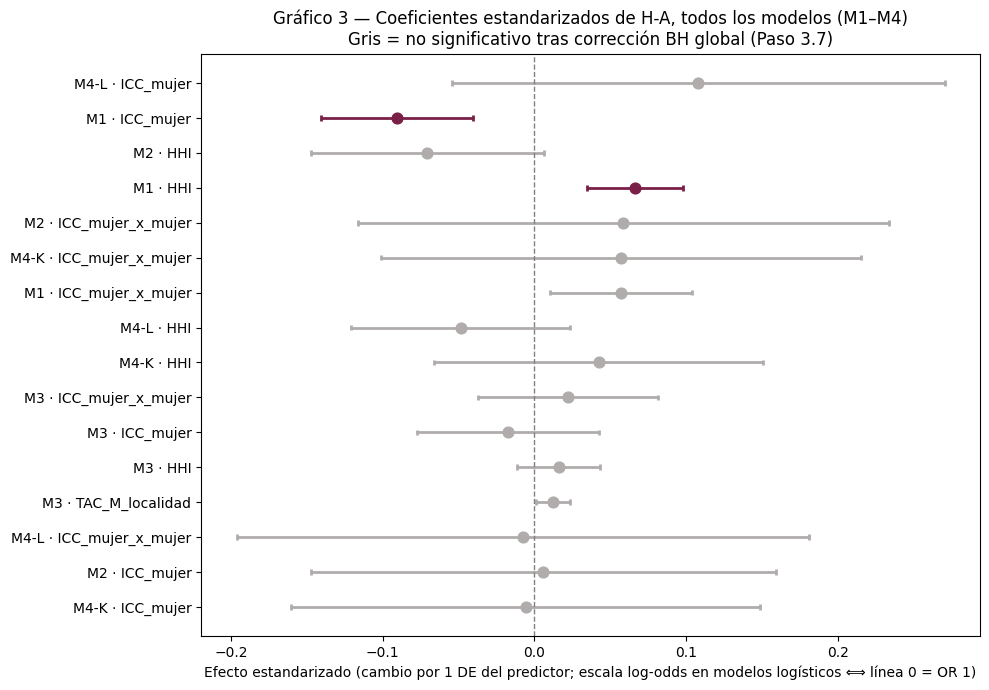


RESULTADOS DEL FOREST PLOT
modelo dependiente         predictor   coef  sd_x  effect_std  ci_low_std  ci_high_std  significativo_bh_global  p_ajustado_bh_global
  M4-K   afronto_K         ICC_mujer -0.016 0.342      -0.006      -0.160        0.149                    False                 0.943
    M2   afronto_M         ICC_mujer  0.017 0.342       0.006      -0.147        0.159                    False                 0.943
  M4-L   afronto_L ICC_mujer_x_mujer -0.024 0.320      -0.008      -0.196        0.181                    False                 0.943
    M3       ICG_B   TAC_M_localidad  0.245 0.049       0.012       0.001        0.023                    False                 0.145
    M3       ICG_B               HHI  0.065 0.248       0.016      -0.011        0.043                    False                 0.500
    M3       ICG_B         ICC_mujer -0.051 0.342      -0.017      -0.077        0.043                    False                 0.701
    M3       ICG_B ICC_mujer_x_muj

In [37]:
import matplotlib.pyplot as plt
import os


# FUNCIÓN: DESVIACIÓN ESTÁNDAR PONDERADA

def sd_ponderada(x, w):
    datos = pd.DataFrame({
        "x": x,
        "w": w
    }).dropna()

    if datos.empty:
        return np.nan

    media_w = np.average(
        datos["x"],
        weights=datos["w"]
    )

    return np.sqrt(
        np.average(
            (datos["x"] - media_w) ** 2,
            weights=datos["w"]
        )
    )


# FUENTES PARA EL FOREST PLOT

fuentes_forest = [
    (
        "M1",
        "IPSJ_C",
        modelo_m1,
        df_m1,
        "fexp_calp_anu",
        "ols"
    ),
    (
        "M2",
        "afronto_M",
        modelo_m2_corregido,
        df_m2,
        "freq_w",
        "logit"
    ),
    (
        "M3",
        "ICG_B",
        modelo_m3,
        df_m3_modelo,
        "fexp_calp_anu",
        "ols"
    ),
    (
        "M4-K",
        "afronto_K",
        modelos_m4["afronto_K"],
        dfs_m4["afronto_K"],
        "fexp_calp_anu",
        "logit"
    ),
    (
        "M4-L",
        "afronto_L",
        modelos_m4["afronto_L"],
        dfs_m4["afronto_L"],
        "fexp_calp_anu",
        "logit"
    ),
]


# RECOLECTAR COEFICIENTES, IC Y SD

filas_forest = []

for (
    nombre_modelo,
    dep_var,
    modelo_obj,
    df_obj,
    w_col,
    family
) in fuentes_forest:

    predictores = [
        p
        for p in [
            "ICC_mujer",
            "ICC_mujer_x_mujer",
            "HHI",
            "TAC_M_localidad"
        ]
        if p in modelo_obj.params.index
    ]

    print(f"\n{nombre_modelo} ({dep_var})")
    print(f"Predictores encontrados: {predictores}")

    for pred in predictores:

        # Coeficiente
        coef = float(modelo_obj.params[pred])

        # Intervalo de confianza
        ci = modelo_obj.conf_int().loc[pred]

        ci_low = float(ci.iloc[0])
        ci_high = float(ci.iloc[1])

        # Verificar columnas
        if pred not in df_obj.columns:
            print(
                f"{nombre_modelo} - {pred}: "
                "no existe en el dataframe."
            )
            continue

        if w_col not in df_obj.columns:
            print(
                f"{nombre_modelo}: "
                f"no existe la ponderación {w_col}."
            )
            continue

        # SD ponderada
        sd_x = sd_ponderada(
            df_obj[pred],
            df_obj[w_col]
        )

        if pd.isna(sd_x):
            print(
                f"{nombre_modelo} - {pred}: "
                "SD ponderada no disponible."
            )
            continue

        sd_x = float(sd_x)

        # Efecto estandarizado
        effect_std = coef * sd_x
        ci_low_std = ci_low * sd_x
        ci_high_std = ci_high * sd_x

        filas_forest.append({
            "modelo": nombre_modelo,
            "dependiente": dep_var,
            "predictor": pred,
            "coef": coef,
            "sd_x": sd_x,
            "effect_std": effect_std,
            "ci_low_std": ci_low_std,
            "ci_high_std": ci_high_std,
            "family": family
        })


# DATAFRAME

df_forest = pd.DataFrame(filas_forest)

if df_forest.empty:
    raise ValueError(
        "No se encontraron coeficientes válidos "
        "para construir el forest plot."
    )


# UNIR SIGNIFICANCIA BH GLOBAL

columnas_bh = [
    "modelo",
    "predictor",
    "significativo_bh_global",
    "p_ajustado_bh_global"
]

faltantes_bh = [
    c
    for c in columnas_bh
    if c not in tabla_global.columns
]

if faltantes_bh:
    raise ValueError(
        f"Faltan columnas en tabla_global: {faltantes_bh}"
    )


df_forest = df_forest.merge(
    tabla_global[columnas_bh],
    on=["modelo", "predictor"],
    how="left"
)


# VERIFICACIÓN DEL MERGE

print("\n" + "=" * 70)
print("VERIFICACIÓN DE SIGNIFICANCIA BH")
print("=" * 70)

print(
    df_forest[
        [
            "modelo",
            "predictor",
            "significativo_bh_global",
            "p_ajustado_bh_global"
        ]
    ].to_string(index=False)
)


# VALORES NO ENCONTRADOS EN TABLA GLOBAL

sin_bh = df_forest[
    df_forest["significativo_bh_global"].isna()
]

if not sin_bh.empty:

    print("\nADVERTENCIA:")
    print(
        "Las siguientes combinaciones no tienen "
        "correspondencia en tabla_global:"
    )

    print(
        sin_bh[
            ["modelo", "predictor"]
        ].to_string(index=False)
    )

    print(
        "\nSe mostrarán como no significativas "
        "en el gráfico."
    )


# CONVERTIR SIGNIFICANCIA A BOOLEAN

df_forest["significativo_bh_global"] = (
    df_forest["significativo_bh_global"]
    .fillna(False)
    .astype(bool)
)


# ETIQUETAS

df_forest["etiqueta"] = (
    df_forest["modelo"]
    + " · "
    + df_forest["predictor"]
)


# ORDENAR POR MAGNITUD

df_forest = (
    df_forest
    .sort_values(
        "effect_std",
        key=lambda x: x.abs(),
        ascending=True
    )
    .reset_index(drop=True)
)


# COLORES

colores = [
    "#7a2048"
    if bool(sig)
    else "#b0acac"
    for sig in df_forest["significativo_bh_global"]
]


# FOREST PLOT

fig, ax = plt.subplots(
    figsize=(10, 7)
)


# DIBUJAR INTERVALOS
#
# NO usamos errorbar().
#
# Dibujamos manualmente:
#
#   ─────────●─────────
#        IC95%   coef
#
# Esto evita el problema de broadcasting de xerr.

for i in range(len(df_forest)):

    row = df_forest.iloc[i]

    efecto = float(row["effect_std"])
    limite_inf = float(row["ci_low_std"])
    limite_sup = float(row["ci_high_std"])

    color = colores[i]

    # Línea horizontal del intervalo de confianza
    ax.hlines(
        y=i,
        xmin=limite_inf,
        xmax=limite_sup,
        color=color,
        linewidth=2
    )

    # Extremo izquierdo
    ax.vlines(
        x=limite_inf,
        ymin=i - 0.08,
        ymax=i + 0.08,
        color=color,
        linewidth=2
    )

    # Extremo derecho
    ax.vlines(
        x=limite_sup,
        ymin=i - 0.08,
        ymax=i + 0.08,
        color=color,
        linewidth=2
    )

    # Punto central del coeficiente
    ax.scatter(
        efecto,
        i,
        color=color,
        s=60,
        zorder=3
    )


# LÍNEA DE REFERENCIA = 0

ax.axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1
)


# EJE Y

ax.set_yticks(
    np.arange(len(df_forest))
)

ax.set_yticklabels(
    df_forest["etiqueta"]
)


# EJE X

ax.set_xlabel(
    "Efecto estandarizado "
    "(cambio por 1 DE del predictor; "
    "escala log-odds en modelos logísticos "
    "⟺ línea 0 = OR 1)"
)


# TÍTULO

ax.set_title(
    "Gráfico 3 — Coeficientes estandarizados de H-A, "
    "todos los modelos (M1–M4)\n"
    "Gris = no significativo tras corrección "
    "BH global (Paso 3.7)"
)


# AJUSTE

plt.tight_layout()


# CREAR CARPETA DE SALIDA

ruta_grafico = (
    "../../outputs/tableau/"
    "grafico3_forest_plot_ha.png"
)

os.makedirs(
    os.path.dirname(ruta_grafico),
    exist_ok=True
)


# GUARDAR GRÁFICO

plt.savefig(
    ruta_grafico,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# TABLA FINAL

tabla_forest_final = df_forest[
    [
        "modelo",
        "dependiente",
        "predictor",
        "coef",
        "sd_x",
        "effect_std",
        "ci_low_std",
        "ci_high_std",
        "significativo_bh_global",
        "p_ajustado_bh_global"
    ]
].copy()


print("\n" + "=" * 70)
print("RESULTADOS DEL FOREST PLOT")
print("=" * 70)

print(
    tabla_forest_final.round(4).to_string(
        index=False
    )
)


# EXPORTAR TABLA

ruta_tabla = (
    "../../outputs/tableau/"
    "grafico3_forest_plot_ha.csv"
)

tabla_forest_final.to_csv(
    ruta_tabla,
    index=False,
    encoding="utf-8-sig"
)


# CONFIRMACIÓN

print("\n" + "=" * 70)
print("EXPORTACIÓN COMPLETADA")
print("=" * 70)

print(
    f"✅ Gráfico guardado en:\n"
    f"   {ruta_grafico}"
)

print(
    f"\n✅ Tabla guardada en:\n"
    f"   {ruta_tabla}"
)

print(
    f"\n✅ Coeficientes graficados: "
    f"{len(df_forest)}"
)

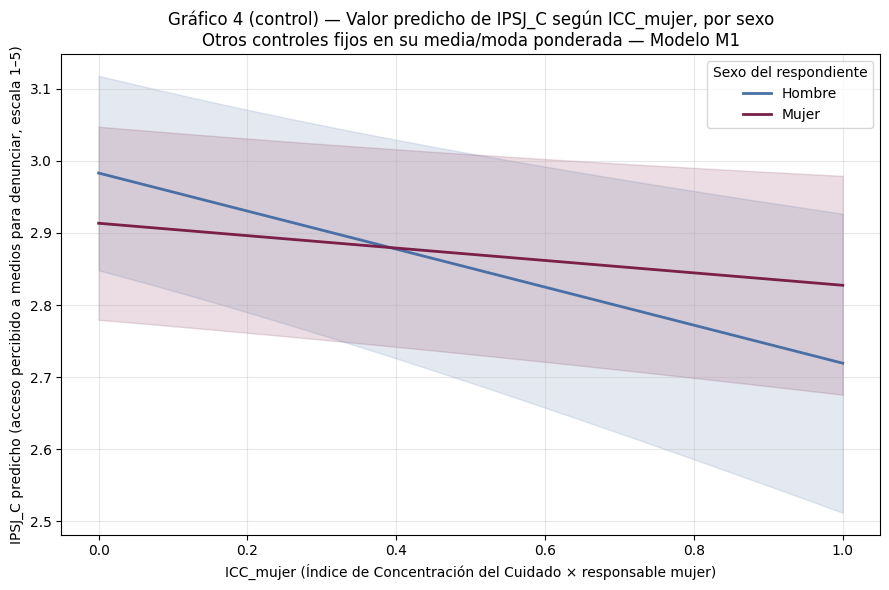

             ICC_mujer        mean      
                   min   max   min   max
sexo_grafico                            
Hombre           0.000 1.000 2.719 2.983
Mujer            0.000 1.000 2.827 2.913


In [38]:
# --- Grilla de predicción: ICC_mujer variando, D1 fijo en Hombre/Mujer, resto en valores representativos ---
grilla_icc = np.linspace(df_m1["ICC_mujer"].min(), df_m1["ICC_mujer"].max(), 50)

# Moda/promedio ponderado de los controles, para mantenerlos constantes en la predicción
estrato_moda = df_m1["estrato_cat"].mode().iat[0]
sexo_jefe_moda = df_m1["sexo_jefe"].mode().iat[0]
gad7_moda = df_m1["GAD7_ordinal"].mode().iat[0]
localidad_moda = df_m1["codigo_localidad"].mode().iat[0]
edad_media = np.average(df_m1["edad"], weights=df_m1["fexp_calp_anu"])
a4_media = np.average(df_m1["A4"], weights=df_m1["fexp_calp_anu"])
pobreza_media = np.average(df_m1["pobreza_subjetiva"], weights=df_m1["fexp_calp_anu"])

filas_pred = []
for sexo in ["Hombre", "Mujer"]:
    es_mujer_val = 1 if sexo == "Mujer" else 0
    for icc in grilla_icc:
        filas_pred.append({
            "ICC_mujer": icc,
            "ICC_mujer_x_mujer": icc * es_mujer_val,
            "HHI": np.average(df_m1["HHI"], weights=df_m1["fexp_calp_anu"]),  # HHI en su media, no varía en este gráfico
            "pobreza_subjetiva": pobreza_media,
            "estrato_cat": estrato_moda,
            "edad": edad_media,
            "edad_cuadrado": edad_media ** 2,
            "D1": sexo,
            "sexo_jefe": sexo_jefe_moda,
            "GAD7_ordinal": gad7_moda,
            "A4": a4_media,
            "codigo_localidad": localidad_moda,
            "sexo_grafico": sexo,
        })

df_pred = pd.DataFrame(filas_pred)

pred_result = modelo_m1.get_prediction(df_pred).summary_frame(alpha=0.05)
df_pred = pd.concat([df_pred.reset_index(drop=True), pred_result.reset_index(drop=True)], axis=1)

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(9, 6))
colores_sexo = {"Hombre": "#4a6fa5", "Mujer": "#7a2048"}

for sexo in ["Hombre", "Mujer"]:
    d = df_pred.loc[df_pred["sexo_grafico"] == sexo]
    ax.plot(d["ICC_mujer"], d["mean"], color=colores_sexo[sexo], label=sexo, linewidth=2)
    ax.fill_between(d["ICC_mujer"], d["mean_ci_lower"], d["mean_ci_upper"],
                     color=colores_sexo[sexo], alpha=0.15)

ax.set_xlabel("ICC_mujer (Índice de Concentración del Cuidado × responsable mujer)")
ax.set_ylabel("IPSJ_C predicho (acceso percibido a medios para denunciar, escala 1–5)")
ax.set_title("Gráfico 4 (control) — Valor predicho de IPSJ_C según ICC_mujer, por sexo\n"
             "Otros controles fijos en su media/moda ponderada — Modelo M1")
ax.legend(title="Sexo del respondiente")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../../docs/grafico4_control_ipsjc_predicho.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_pred.groupby("sexo_grafico")[["ICC_mujer", "mean"]].agg(["min", "max"]).round(3))